In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from outlier_cleaner import OutlierCleaner

# Preprocessing and pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline


# Sklearn libraries
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor,
    VotingRegressor, StackingRegressor
)

# Sklearn metrics
from sklearn.metrics import r2_score, mean_squared_error
from extended_sklearn_metrics import evaluate_model_with_cross_validation

# Extra model
import xgboost as xgb

In [2]:
# Load the csv
df = pd.read_csv('./student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
# Check everything before start
df.shape 
# so we have 1000 data and 16 columns

(1000, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [9]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [11]:
df.duplicated().sum()

0

In [13]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [15]:
# so from here we have 91 missing values

In [17]:
df['parental_education_level'].value_counts()

parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64

## Replace missing values with unknown

In [20]:
df.loc[df['parental_education_level'].isnull(), 'parental_education_level'] = 'Unknown'

In [22]:
# Replace with mode
# mode = df['parental_education_level'].mode()
# df.dropna(subset=['parental_education_level'], inplace=True)

In [24]:
# Drop it
# df.dropna(['parental_education_level'], inplace=True)

In [26]:
# replace with unknown instead of drop or replace with mode/median

In [28]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

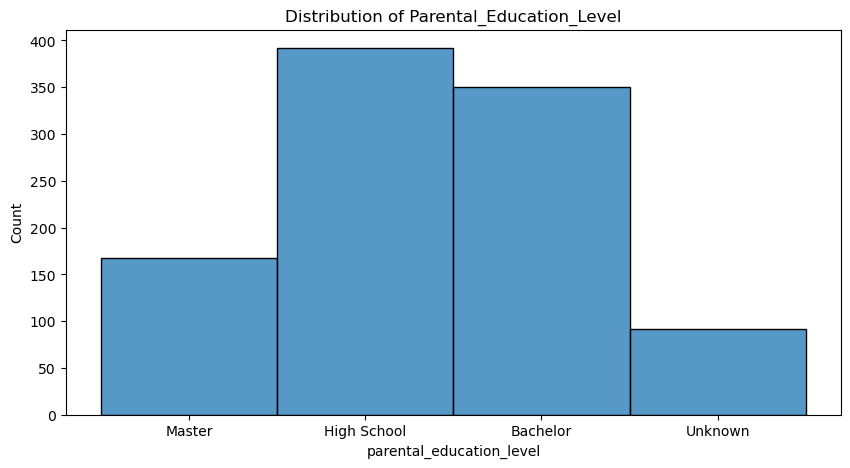

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(df['parental_education_level'])
plt.title('Distribution of Parental_Education_Level')
plt.show()

# high school is the highest 
# majority parents with high school education 

## EDA (Quick overview everything)

In [33]:
# df.columns

## Numeric Features

In [36]:
df['age'].mode()

0    20
Name: age, dtype: int64

In [38]:
df['age'].median()

20.0

In [40]:
df['age'].skew()

0.0084371397444062

In [42]:
df.groupby('gender')['age'].mean()

gender
Female    20.422037
Male      20.559748
Other     20.666667
Name: age, dtype: float64

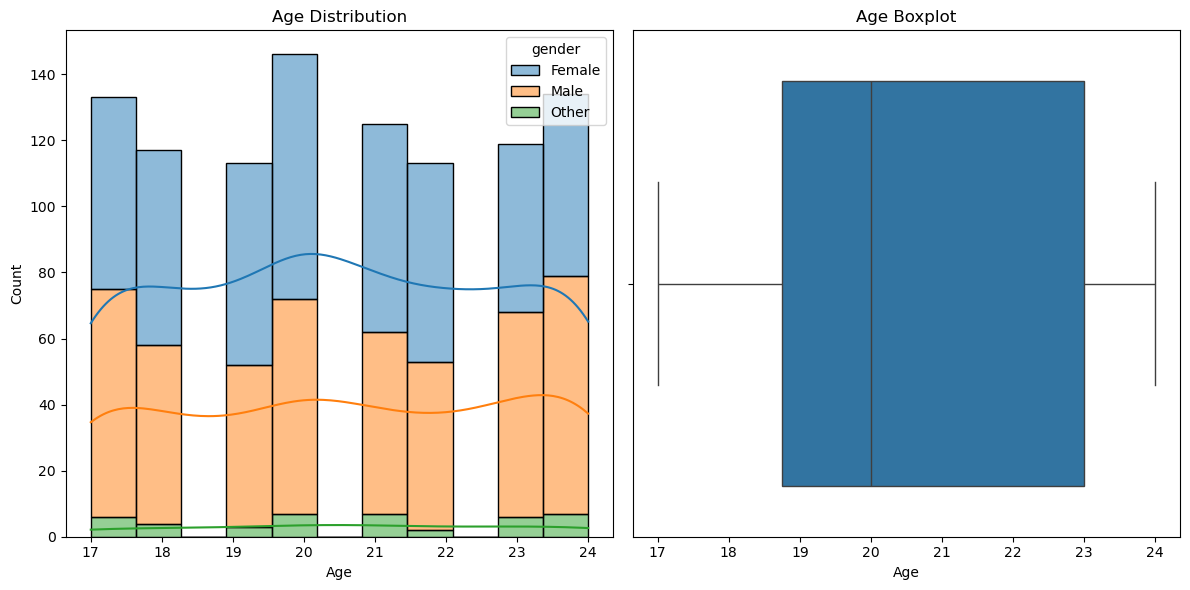

In [44]:
# age
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.histplot(df, x='age', hue='gender', multiple='stack', kde=True) # multiple stack shows gender breakdown
plt.title('Age Distribution')
plt.xlabel('Age')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='age')
plt.title('Age Boxplot')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

# from histogram, highest age peak is 20
# is symmetic and not skewed (evenly spread 20)

# from boxplot, median age is 20
# no outlier (extreme value like 10 or 40 years old), not too young or old

## so what cause this happen
# most student in university is 18-24 (diploma or degree)

In [46]:
df['study_hours_per_day'].mode()

0    3.5
Name: study_hours_per_day, dtype: float64

In [48]:
df['study_hours_per_day'].median()

3.5

In [50]:
df['study_hours_per_day'].skew()

0.05425310140811603

In [52]:
df.groupby('gender')['study_hours_per_day'].mean()

gender
Female    3.583784
Male      3.510692
Other     3.611905
Name: study_hours_per_day, dtype: float64

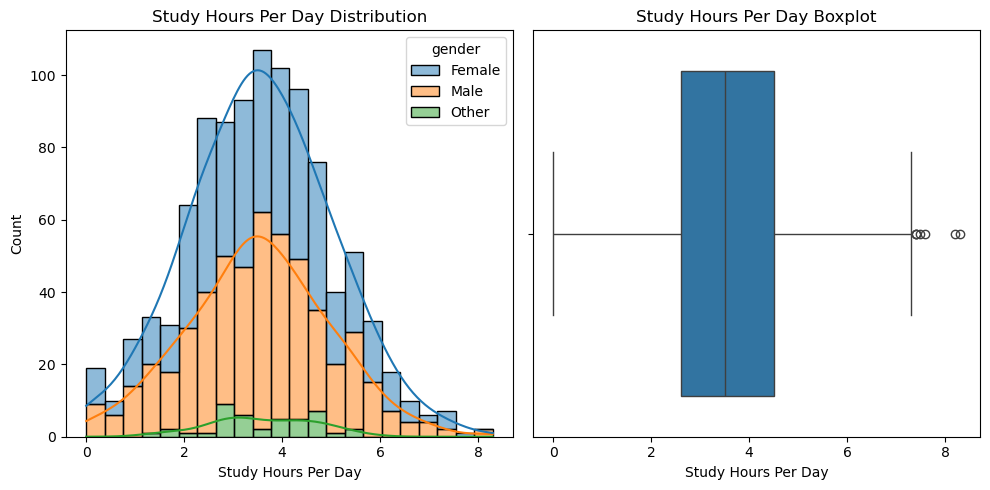

In [54]:
# study_hours_per_day
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='study_hours_per_day', hue='gender', multiple='stack', kde=True)
plt.title('Study Hours Per Day Distribution')
plt.xlabel('Study Hours Per Day')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='study_hours_per_day')
plt.title('Study Hours Per Day Boxplot')
plt.xlabel('Study Hours Per Day')
plt.tight_layout()
plt.show()

# from histogram, highest peak is 3.5 to 4
# bell-shaped

# from boxplot, median study hour is 3.5
# slightly right skewed and with outlier (> 7 or 7.5 hours)

## so what cause this happen
# some students with scholarships, in competitive fiels (um, usm) or prepare for exam might study longer

In [56]:
# df.columns

In [58]:
df['social_media_hours'].mode()

0    3.1
Name: social_media_hours, dtype: float64

In [60]:
df['social_media_hours'].median()

2.5

In [62]:
df['social_media_hours'].skew()

0.11980520318308562

In [64]:
df.groupby('gender')['social_media_hours'].mean()

gender
Female    2.503950
Male      2.499371
Other     2.592857
Name: social_media_hours, dtype: float64

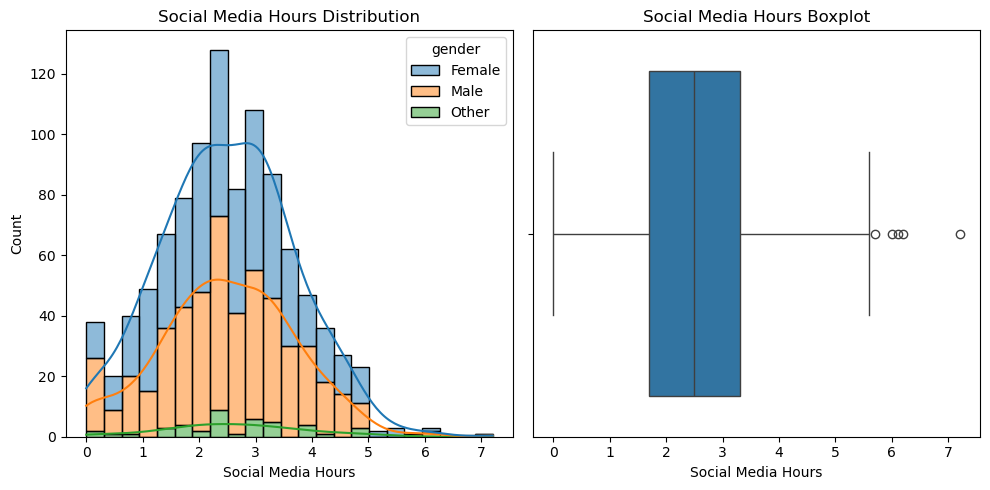

In [66]:
# social_media_hours
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='social_media_hours', hue='gender', multiple='stack', kde=True)
plt.title('Social Media Hours Distribution')
plt.xlabel('Social Media Hours')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='social_media_hours')
plt.title('Social Media Hours Boxplot')
plt.xlabel('Social Media Hours')
plt.tight_layout()
plt.show()

# from histogram, highest peak is 2.5 to 3
# slightly right-skewed curve

# from boxplot, median social media hour is 2.5
# right skewed and with outlier (> 5.5 or 6)

## so what cause this happen
# some students are heavy social media users which possibly spend more time on apps like TikTok or Instagram

In [68]:
df['netflix_hours'].mode()

0    0.0
Name: netflix_hours, dtype: float64

In [70]:
df['netflix_hours'].median()

1.8

In [72]:
df['netflix_hours'].skew()

0.23715439564540441

In [74]:
df.groupby('gender')['netflix_hours'].mean()

gender
Female    1.797921
Male      1.820755
Other     2.057143
Name: netflix_hours, dtype: float64

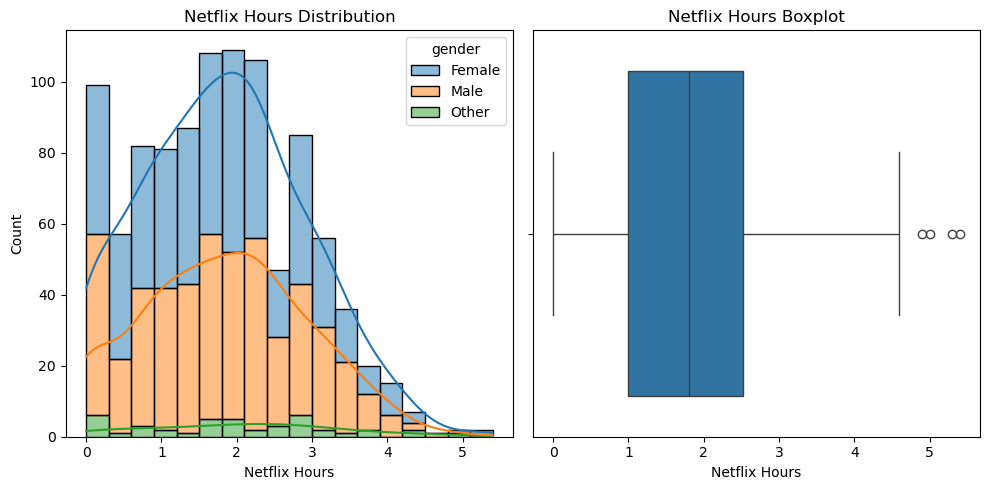

In [76]:
# netflix_hours
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='netflix_hours', hue='gender', multiple='stack', kde=True)
plt.title('Netflix Hours Distribution')
plt.xlabel('Netflix Hours')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='netflix_hours')
plt.title('Netflix Hours Boxplot')
plt.xlabel('Netflix Hours')
plt.tight_layout()
plt.show()

# from histogram, highest peak is 1.5 to 2
# right-skewed curve with long tail > 3.5 hours

# from boxplot, median netflix hour is 1.8
# right skewed and with outlier (> 4.5 or 5 hours)

## so what cause this happen
# some students may spend long hours to watch netflix during weekends or sem break (bored)

In [78]:
# df.columns

In [80]:
df['attendance_percentage'].mode()

0    100.0
Name: attendance_percentage, dtype: float64

In [82]:
df['attendance_percentage'].median()

84.4

In [84]:
df['attendance_percentage'].skew()

-0.23781042684597256

In [86]:
df.groupby('gender')['attendance_percentage'].mean()

gender
Female    84.371518
Male      83.894549
Other     84.078571
Name: attendance_percentage, dtype: float64

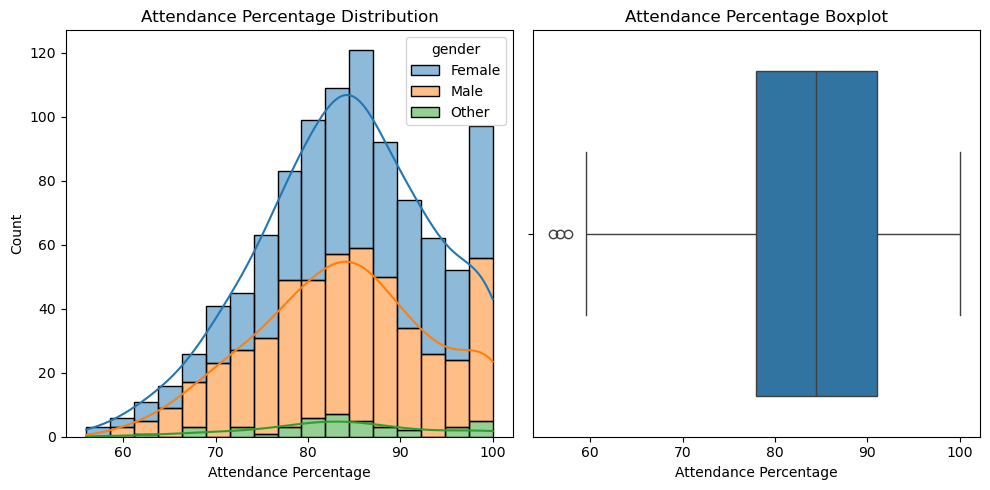

In [88]:
# attendance_percentage
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='attendance_percentage', hue='gender', multiple='stack', kde=True)
plt.title('Attendance Percentage Distribution')
plt.xlabel('Attendance Percentage')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='attendance_percentage')
plt.title('Attendance Percentage Boxplot')
plt.xlabel('Attendance Percentage')
plt.tight_layout()
plt.show()

# from histogram, highest peak is 80 to 85
# slightly left-skewed

# from boxplot, median attendance is 84.4
# left skewed and with outlier (< 60)

## so what cause this happen
# most students attend class regularly since less than 80 is not able to join the exam
# few students have low attendance due to illness, personal issues, or lack of motivation

In [90]:
df['sleep_hours'].mode()

0    6.5
Name: sleep_hours, dtype: float64

In [92]:
df['sleep_hours'].median()

6.5

In [94]:
df['sleep_hours'].skew()

0.09148397227093791

In [96]:
df.groupby('gender')['sleep_hours'].mean()

gender
Female    6.471726
Male      6.438994
Other     6.804762
Name: sleep_hours, dtype: float64

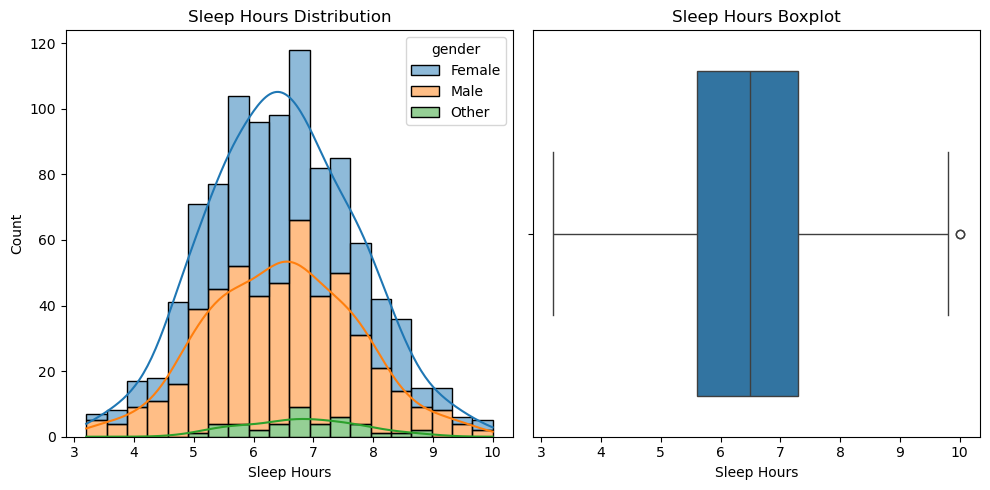

In [98]:
# sleep_hours
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='sleep_hours', hue='gender', multiple='stack', kde=True)
plt.title('Sleep Hours Distribution')
plt.xlabel('Sleep Hours')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='sleep_hours')
plt.title('Sleep Hours Boxplot')
plt.xlabel('Sleep Hours')
plt.tight_layout()
plt.show()

# from histogram, highest peak is 6.5
# bell-shaped and symmetric

# from boxplot, median sleep hour is 6.5
# slightly right skewed (> 9.5)

## so what cause this happen
# most students sleep around 6 to 7 hours (basically is true, 8 hours is almost impossible unless weekend, sem break)
# uni students have quite a lot assignment, project and courses

In [100]:
df['exam_score'].mode()

0    100.0
Name: exam_score, dtype: float64

In [102]:
df['exam_score'].median()

70.5

In [104]:
df['exam_score'].skew()

-0.15635065547132798

In [106]:
df.groupby('gender')['exam_score'].mean()

gender
Female    69.741372
Male      69.368344
Other     70.647619
Name: exam_score, dtype: float64

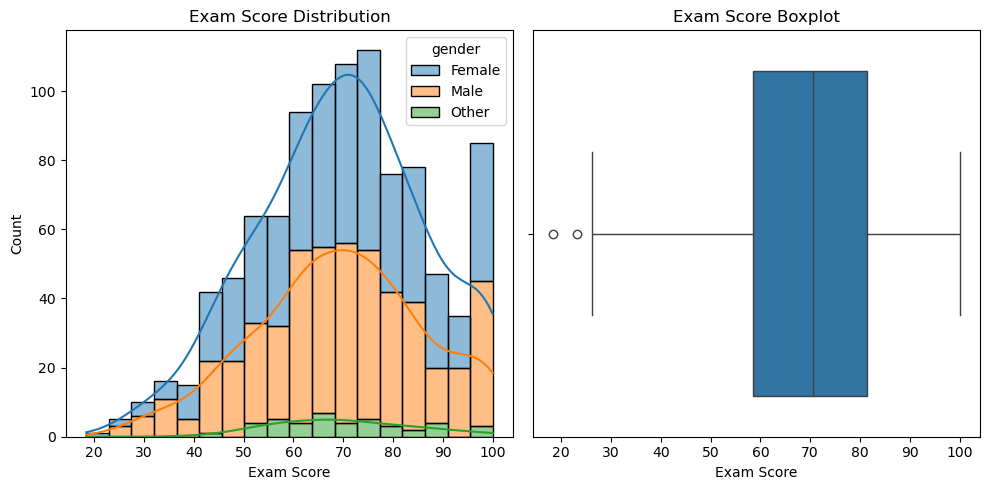

In [108]:
# exam_score
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='exam_score', hue='gender', multiple='stack', kde=True)
plt.title('Exam Score Distribution')
plt.xlabel('Exam Score')

plt.subplot(1, 2, 2)
sns.boxplot(df, x='exam_score')
plt.title('Exam Score Boxplot')
plt.xlabel('Exam Score')
plt.tight_layout()
plt.show()

# from histogram, highest peak is 70
# left-skewed

# from boxplot, median exam score is 70.5
# left skewed and with outlier (< 25)

## so what cause this happen
# most students perform well because study habits and attendance
# few students score low due to stress, lack of preparation or study habits

## Skewness for all numeric

In [111]:
# df.columns

In [113]:
numeric_cols = ['age','study_hours_per_day','social_media_hours','netflix_hours','attendance_percentage', 'sleep_hours','exam_score']
df[numeric_cols].skew()

age                      0.008437
study_hours_per_day      0.054253
social_media_hours       0.119805
netflix_hours            0.237154
attendance_percentage   -0.237810
sleep_hours              0.091484
exam_score              -0.156351
dtype: float64

## Categorical features (Plot and unique values)

In [116]:
# df.columns

In [118]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [120]:
df['gender'].mode()

0    Female
Name: gender, dtype: object

In [122]:
df['gender'].value_counts()

gender
Female    481
Male      477
Other      42
Name: count, dtype: int64

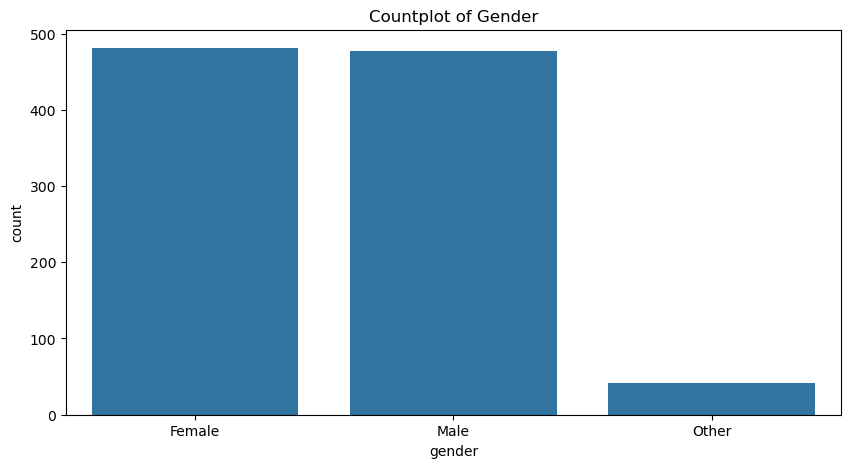

In [124]:
# Gender count
plt.figure(figsize=(10,5))
sns.countplot(df, x='gender')
plt.title('Countplot of Gender')
plt.show()

# the count of both male and female is almost the same

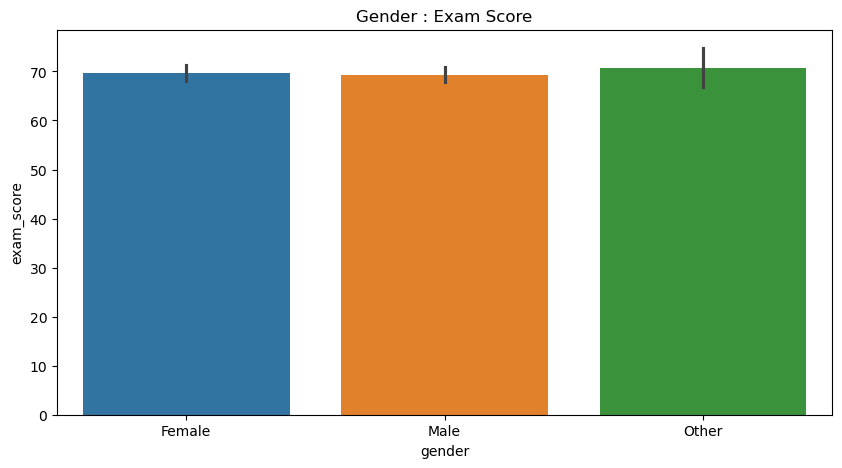

In [126]:
# Gender
plt.figure(figsize=(10,5))
sns.barplot(df, x='gender', y='exam_score', hue='gender')
plt.title('Gender : Exam Score')
plt.show()

# from the barplot, we can see the average exam score is almost the same

## so why this happen
# due to the dataset, we only have 1000 data so we cant actually show big difference 
# and another thing is gender just a label, it doesnt define much on behavior or habit

In [128]:
df['part_time_job'].unique()

array(['No', 'Yes'], dtype=object)

In [130]:
df['part_time_job'].mode()

0    No
Name: part_time_job, dtype: object

In [132]:
df['part_time_job'].value_counts()

part_time_job
No     785
Yes    215
Name: count, dtype: int64

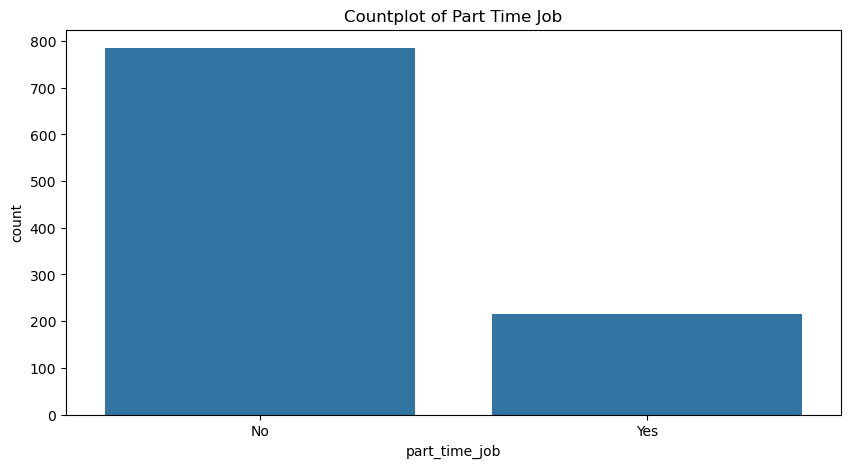

In [134]:
# Part time job count
plt.figure(figsize=(10,5))
sns.countplot(df, x='part_time_job')
plt.title('Countplot of Part Time Job')
plt.show()

# most students dont have part time job

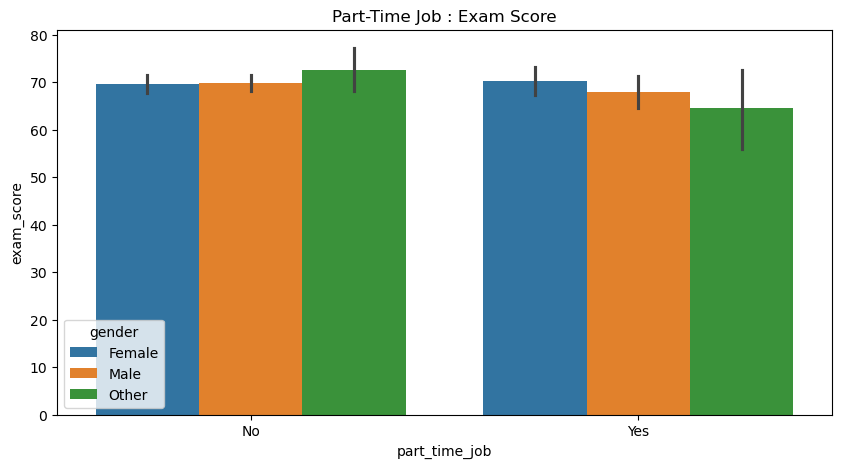

In [136]:
# Part time
plt.figure(figsize=(10,5))
sns.barplot(df, x='part_time_job', y='exam_score', hue='gender')
plt.title('Part-Time Job : Exam Score')
plt.show()

# from the barplot, students that dont have part time job have higher average exam score 

## why this happen
# students that have part time may have less time and energy to focus on study (lack of rest or sleep)

In [138]:
df['diet_quality'].unique()

array(['Fair', 'Good', 'Poor'], dtype=object)

In [140]:
df['diet_quality'].mode()

0    Fair
Name: diet_quality, dtype: object

In [142]:
df['diet_quality'].value_counts()

diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64

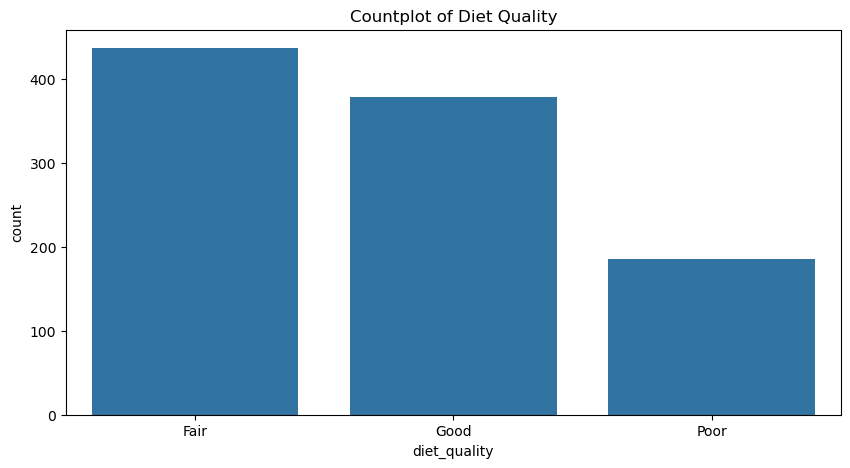

In [144]:
# Diet quality count
plt.figure(figsize=(10,5))
sns.countplot(df, x='diet_quality')
plt.title('Countplot of Diet Quality')
plt.show()

# most students have fair diet quality

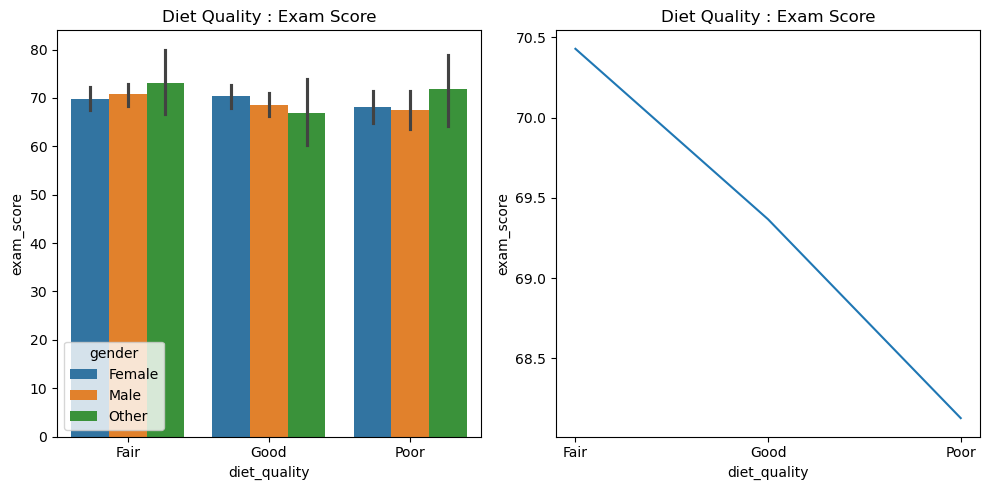

In [146]:
# Diet
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.barplot(df, x='diet_quality', y='exam_score', hue='gender')
plt.title('Diet Quality : Exam Score')

plt.subplot(1, 2, 2)
avg_diet = df.groupby('diet_quality')['exam_score'].mean().reset_index()
sns.lineplot(avg_diet, x='diet_quality', y='exam_score')
plt.title('Diet Quality : Exam Score')
plt.tight_layout()
plt.show()

# from both graph, students with a fair diet quality have highest exam scores

# before that how u assume u have fair or good diet quality
# (fair could be consistent like 3 meals a day, good could be like very healthy meal which means meals to get fit or daily protein needed)

## why this happen 
# good diet quality normallly is chicken breast, oats, veggie (for fit person) and is hard to maintain
# fair diet quality students do better because eat regularly, while those with good diets probably skip meal (lose weight to get fit) which may cause them get tired, hungry or distracted
# this could be a bias issues

In [147]:
df['exercise_frequency'].unique()

array([6, 1, 4, 3, 2, 0, 5], dtype=int64)

In [150]:
df['exercise_frequency'].mode()

0    3
Name: exercise_frequency, dtype: int64

In [152]:
df['exercise_frequency'].value_counts()

exercise_frequency
3    153
6    152
5    149
1    146
0    144
4    134
2    122
Name: count, dtype: int64

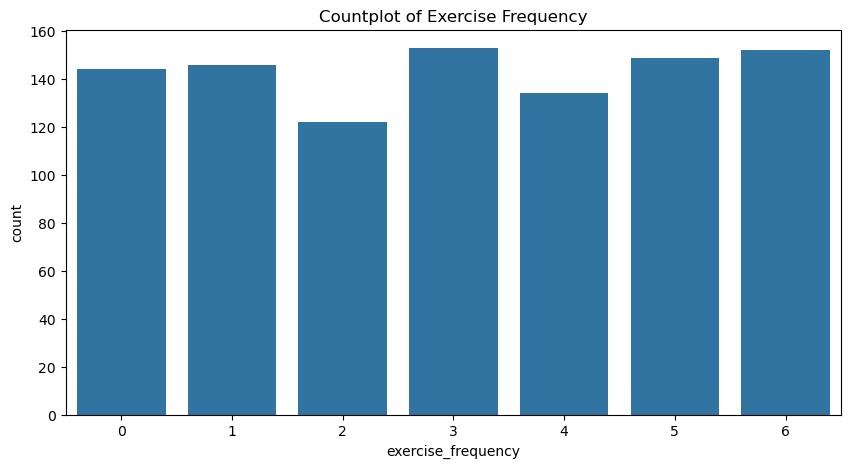

In [154]:
# Exercise frequency count
plt.figure(figsize=(10,5))
sns.countplot(df, x='exercise_frequency')
plt.title('Countplot of Exercise Frequency')
plt.show()

# most students exercise 3 times a week

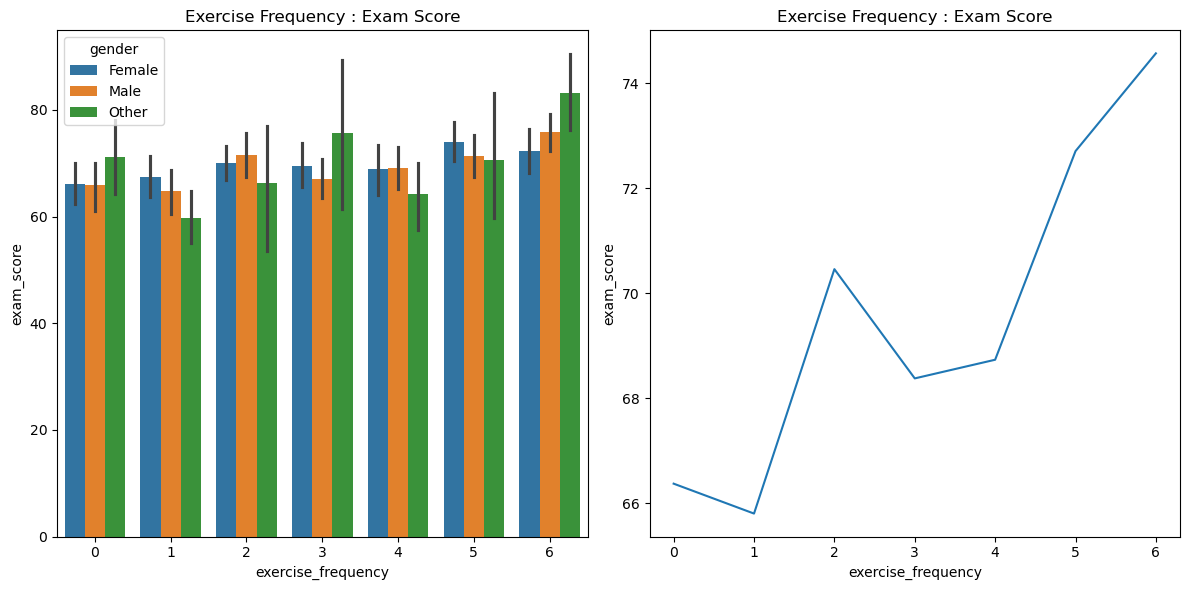

In [156]:
# Exercise
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.barplot(df, x='exercise_frequency', y='exam_score', hue='gender')
plt.title('Exercise Frequency : Exam Score')

plt.subplot(1, 2, 2)
avg_exercise = df.groupby('exercise_frequency')['exam_score'].mean().reset_index()
sns.lineplot(avg_exercise, x='exercise_frequency', y='exam_score')
plt.title('Exercise Frequency : Exam Score')
plt.tight_layout()
plt.show()

# from both graph, students who exercise more have higher average exam scores

## why this happen
# as we know, exercise have a lot of benefit (reduce stress, better sleep, increase blood flow and etc)
# student who exercise more have better focus, energy and stress control

In [157]:
df['parental_education_level'].unique()

array(['Master', 'High School', 'Bachelor', 'Unknown'], dtype=object)

In [160]:
df['parental_education_level'].mode()

0    High School
Name: parental_education_level, dtype: object

In [162]:
df['parental_education_level'].value_counts()

parental_education_level
High School    392
Bachelor       350
Master         167
Unknown         91
Name: count, dtype: int64

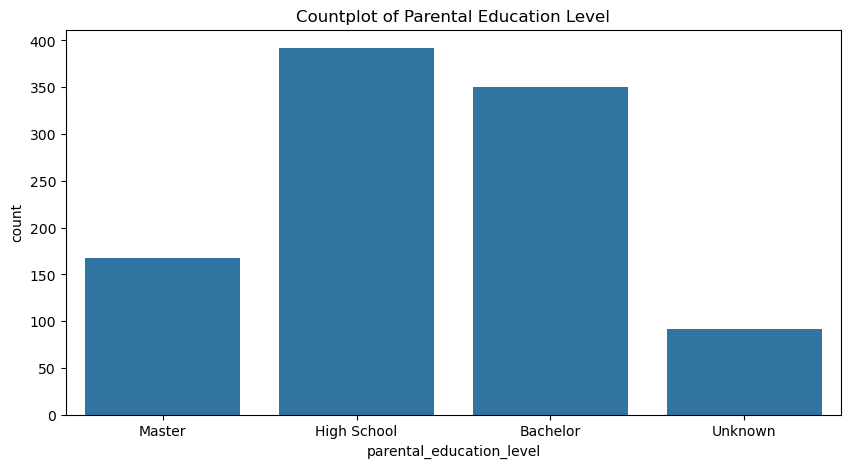

In [164]:
# Education count
plt.figure(figsize=(10,5))
sns.countplot(df, x='parental_education_level')
plt.title('Countplot of Parental Education Level')
plt.show()

# most parents have high school education

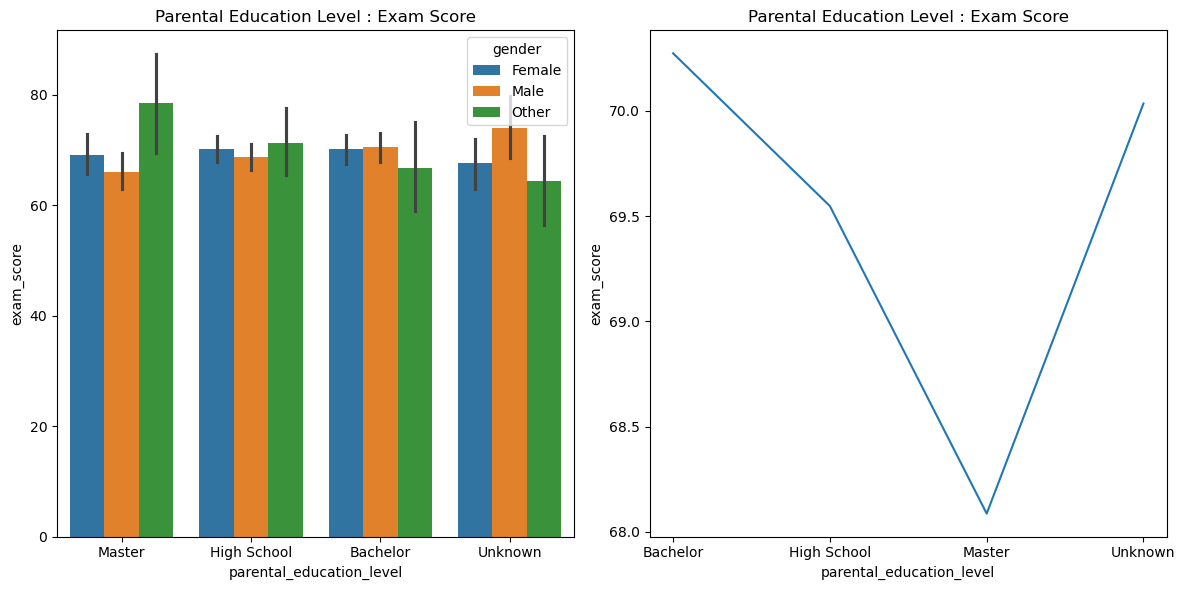

In [166]:
# Education
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.barplot(df, x='parental_education_level', y='exam_score', hue='gender')
plt.title('Parental Education Level : Exam Score')

plt.subplot(1, 2, 2)
avg_education = df.groupby('parental_education_level')['exam_score'].mean().reset_index()
sns.lineplot(avg_education, x='parental_education_level', y='exam_score')
plt.title('Parental Education Level : Exam Score')
plt.tight_layout()
plt.show()

# from both graph, parents with Bachelor education have highest score while master education is the lowest

## why this happen
# high educated = high-demand career (doctor, lawyer, engineering) mostly means they spend less time with their children (less care and support)
# students face quite a lot of pressure (stress) because they have to meet the expectation
# parent with high school education may encourage their children to study hard because they want their child have better opportunities than they had (motivate and support)

In [167]:
df['internet_quality'].unique()

array(['Average', 'Poor', 'Good'], dtype=object)

In [170]:
df['internet_quality'].mode()

0    Good
Name: internet_quality, dtype: object

In [172]:
df['internet_quality'].value_counts()

internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64

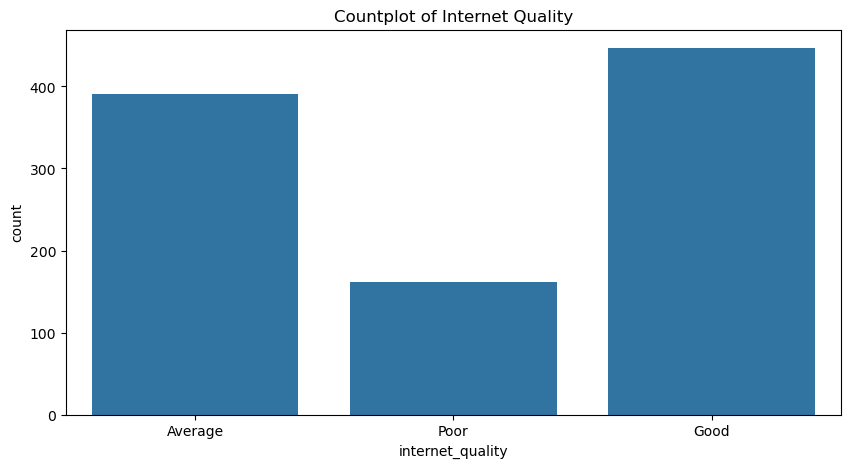

In [174]:
# Internet quality count
plt.figure(figsize=(10,5))
sns.countplot(df, x='internet_quality')
plt.title('Countplot of Internet Quality')
plt.show()

# most student have good internet quality

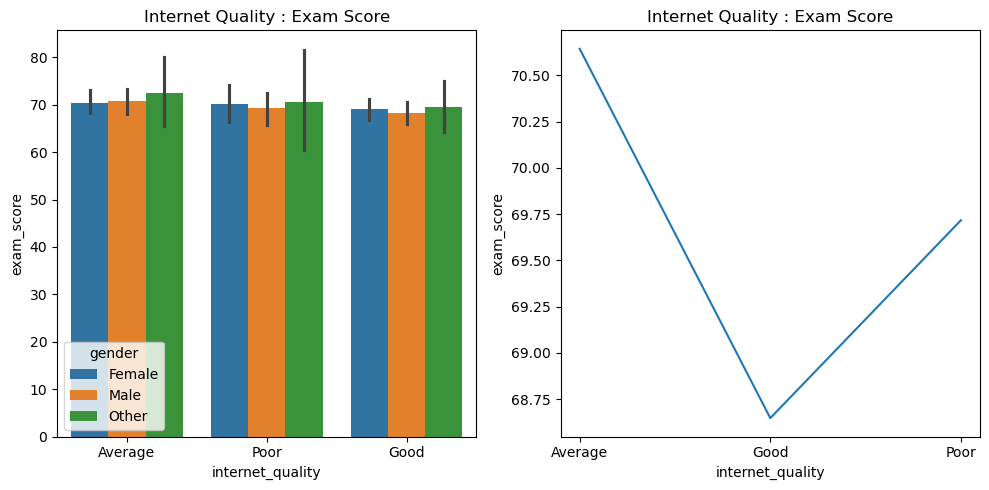

In [176]:
# Internet
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.barplot(df, x='internet_quality', y='exam_score', hue='gender')
plt.title('Internet Quality : Exam Score')

plt.subplot(1, 2, 2)
avg_internet = df.groupby('internet_quality')['exam_score'].mean().reset_index()
sns.lineplot(avg_internet, x='internet_quality', y='exam_score')
plt.title('Internet Quality : Exam Score')
plt.tight_layout()
plt.show()

# from both graph, student with average internet quality have highest score while good internet quality have the lowest score

## so why this happen
# average internet quality can access to study material or website but not good enough for online games or movies (fps games, 4k netflix, tiktok may lagging)
# while with good internet quality, they can do or play whatever they want which cause they have a bad score
# student with poor internet quality may having problem when they face challenge in study and want to seek for help online (miss assignments?)

In [177]:
df['mental_health_rating'].unique()

array([ 8,  1,  4, 10,  3,  9,  7,  5,  2,  6], dtype=int64)

In [180]:
df['mental_health_rating'].mode()

0    4
Name: mental_health_rating, dtype: int64

In [182]:
df['mental_health_rating'].value_counts()

mental_health_rating
4     110
6     108
8     105
3     105
1     102
10     99
5      99
2      94
7      91
9      87
Name: count, dtype: int64

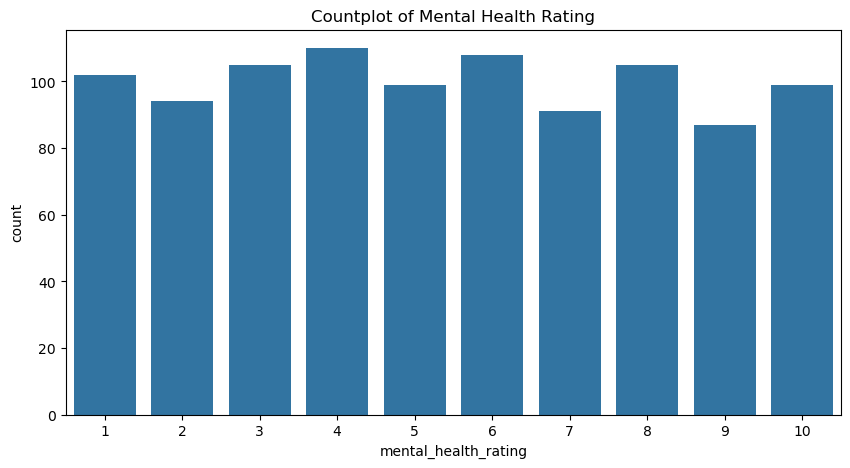

In [184]:
# Mental health rating count
plt.figure(figsize=(10,5))
sns.countplot(df, x='mental_health_rating')
plt.title('Countplot of Mental Health Rating')
plt.show()

# most students rated their mental health as 4

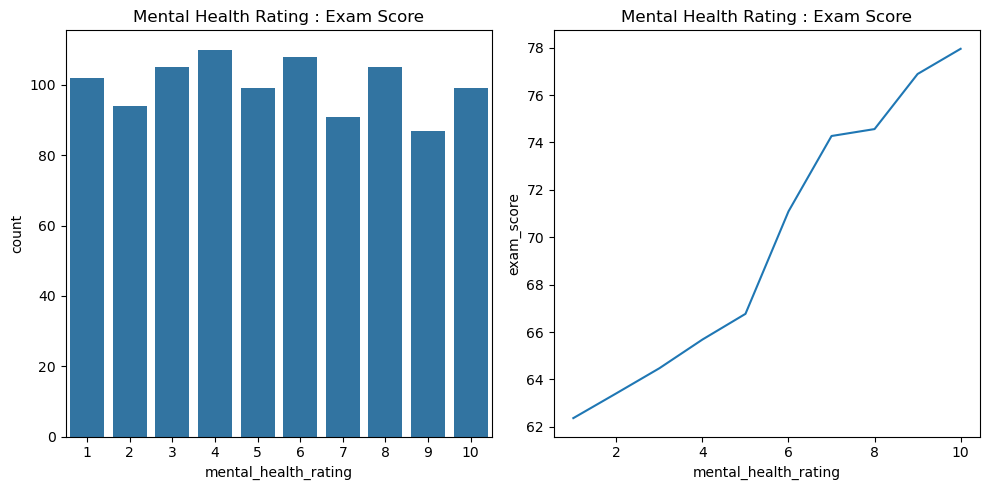

In [186]:
# Health
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.countplot(df, x='mental_health_rating')
plt.title('Mental Health Rating : Exam Score')

plt.subplot(1, 2, 2)
avg_health = df.groupby('mental_health_rating')['exam_score'].mean().reset_index()
sns.lineplot(avg_health, x='mental_health_rating', y='exam_score')
plt.title('Mental Health Rating : Exam Score')
plt.tight_layout()
plt.show()

# from both graph, students with higher mental health ratings have higher exam score

## so why this happen
# students with better mental health is more focus, confident, and motivated to study (get better sleep, energy, and time management)
# while students with low mental health may facing issues (lack of sleep, depression, anxious) which cause low score

In [188]:
df['extracurricular_participation'].unique()

array(['Yes', 'No'], dtype=object)

In [190]:
df['extracurricular_participation'].mode()

0    No
Name: extracurricular_participation, dtype: object

In [192]:
df['extracurricular_participation'].value_counts()

extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64

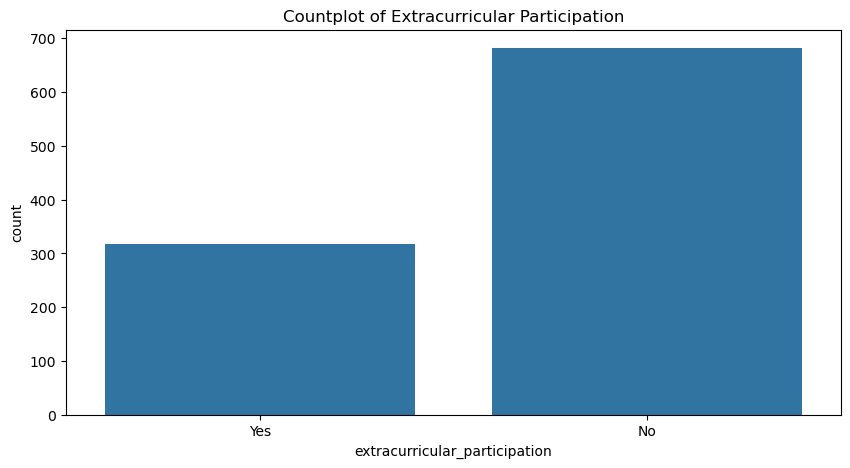

In [194]:
# Extracurricular participation count
plt.figure(figsize=(10,5))
sns.countplot(df, x='extracurricular_participation')
plt.title('Countplot of Extracurricular Participation')
plt.show()

# most students dont participate in extracurricular

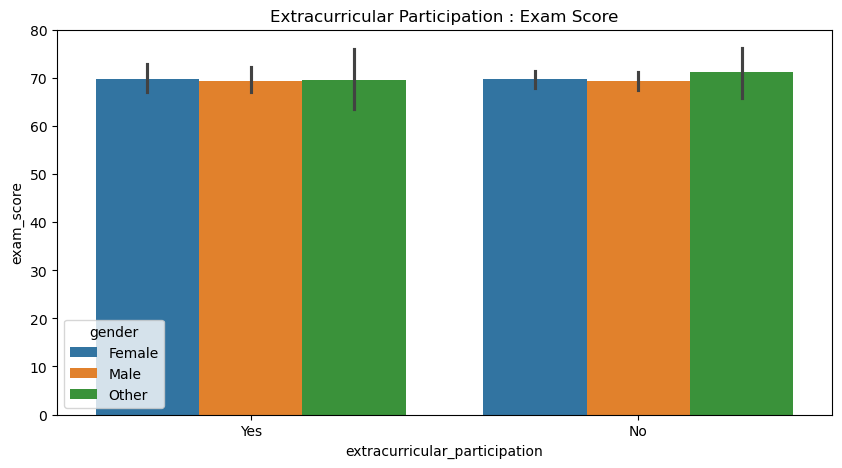

In [196]:
# Extracurricular
plt.figure(figsize=(10,5))
sns.barplot(df, x='extracurricular_participation', y='exam_score', hue='gender')
plt.title('Extracurricular Participation : Exam Score')
plt.show()

# from both graph, both average exam score is almost the same

## so why this happen
# students that participate in extracurricular can gain confidence, communication and leadership, but at the same time they lose their study time (tired)
# while students that dont participate have more time to study/revision and rest

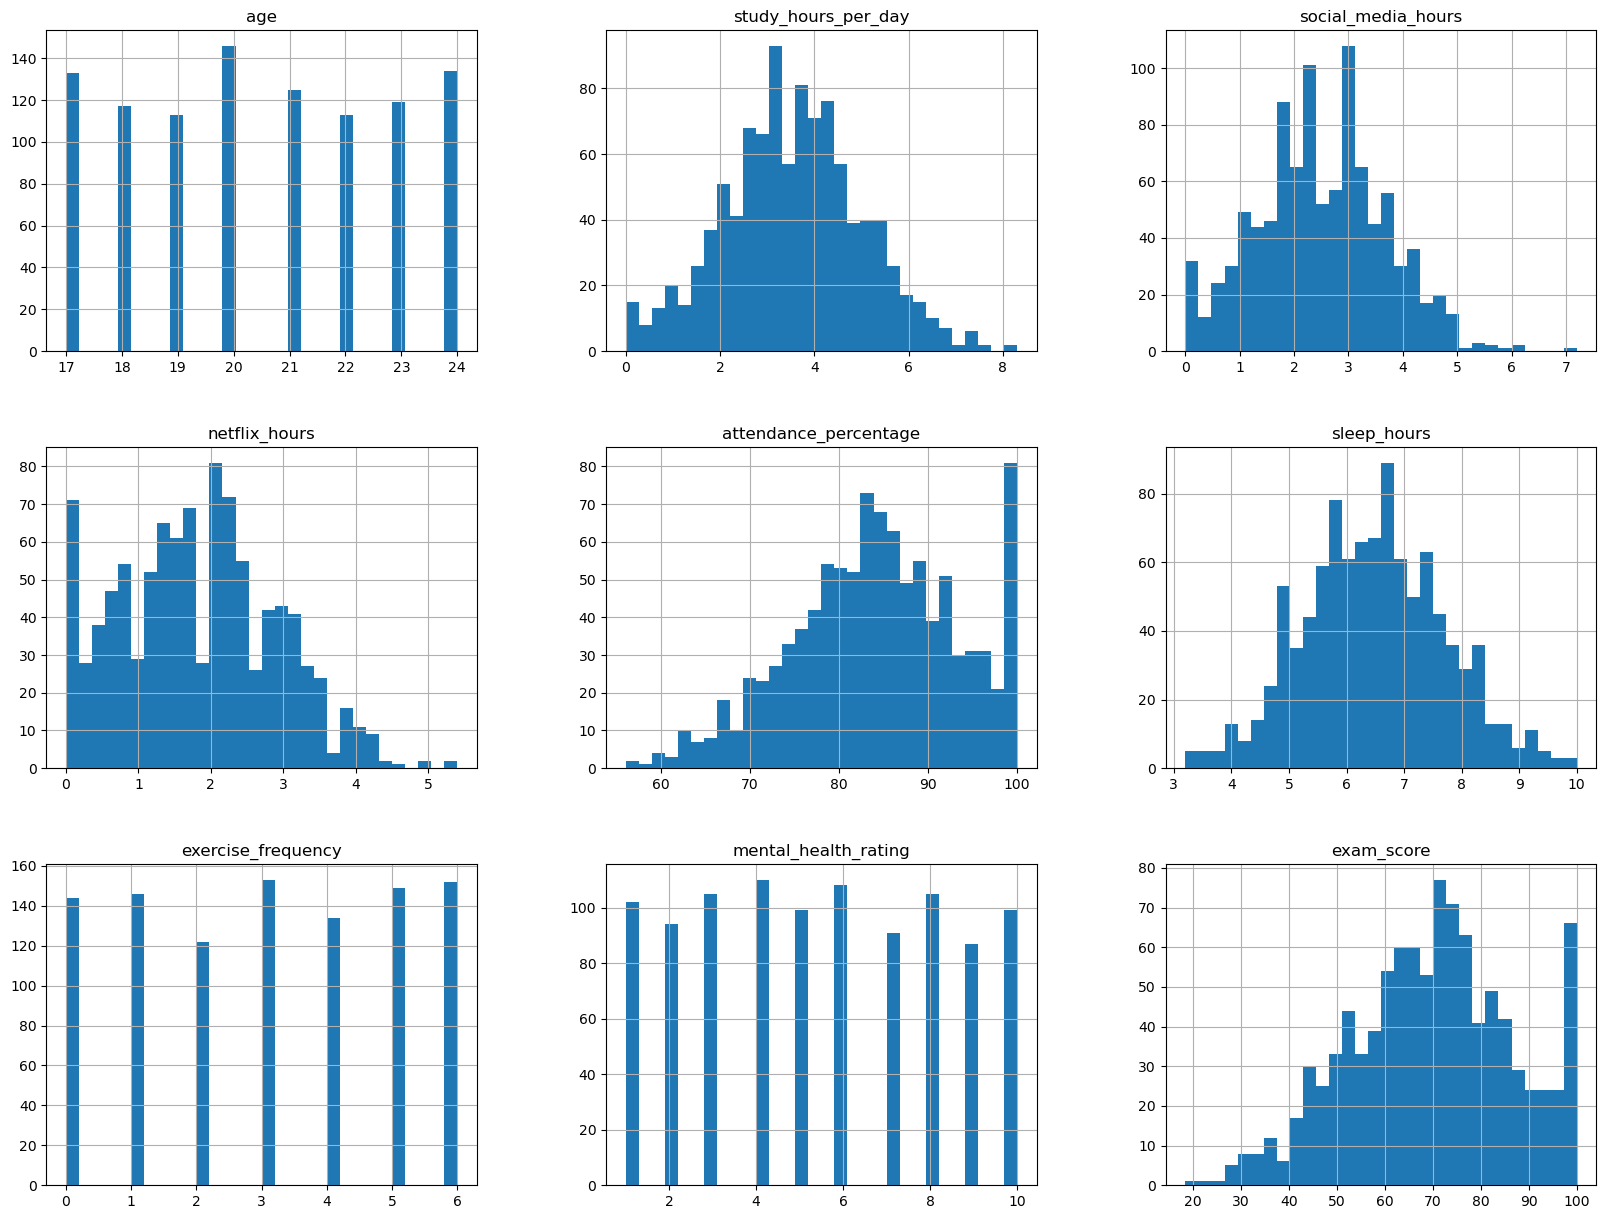

In [198]:
df.hist(bins=30, figsize=(20, 15))
plt.show()

## Encoding

In [200]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [203]:
df = df.drop(columns=['student_id']) 
df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [205]:
# clean the outlier
cleaner = OutlierCleaner(df)
numerical_features = df.select_dtypes(include=['int64', 'float64', 'int32'])
df, info = cleaner.clean_columns(
    columns = numerical_features,
    method = 'zscore',
    show_progress = True
)

Cleaning columns:   1%|▌                                                             | 9/1000 [00:00<00:01, 941.72it/s]


In [207]:
# df.columns

In [209]:
ordinal_cols = ['part_time_job', 'diet_quality', 'exercise_frequency','parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']
nominal_cols = ['gender']
encoder = LabelEncoder()
encoder_hot = OneHotEncoder(sparse_output=False)
for col in ordinal_cols:
    df[col + '_encoded'] = encoder.fit_transform(df[col])
encoded_data = encoder_hot.fit_transform(df[nominal_cols])
encoded_feature_names = encoder_hot.get_feature_names_out(nominal_cols)
nominal_df = pd.DataFrame(encoded_data, columns=encoded_feature_names)
df2 = pd.concat([df.reset_index(drop=True), nominal_df.reset_index(drop=True)], axis=1)
df2 = df2.drop(columns=['part_time_job', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation','gender'])
encoded_df = df2.select_dtypes(include=['int64', 'float64', 'int32'])
encoded_df

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exam_score,part_time_job_encoded,diet_quality_encoded,exercise_frequency_encoded,parental_education_level_encoded,internet_quality_encoded,mental_health_rating_encoded,extracurricular_participation_encoded,gender_Female,gender_Male,gender_Other
0,23,0.0,1.2,1.1,85.0,8.0,56.2,0,0,6,2,0,7,1,1.0,0.0,0.0
1,20,6.9,2.8,2.3,97.3,4.6,100.0,0,1,6,1,0,7,0,1.0,0.0,0.0
2,21,1.4,3.1,1.3,94.8,8.0,34.3,0,2,1,1,2,0,0,0.0,1.0,0.0
3,23,1.0,3.9,1.0,71.0,9.2,26.8,0,2,4,2,1,0,1,1.0,0.0,0.0
4,19,5.0,4.4,0.5,90.9,4.9,66.4,0,0,3,2,1,0,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,21,2.6,0.5,1.6,77.0,7.5,76.1,0,0,2,1,1,5,1,1.0,0.0,0.0
988,17,2.9,1.0,2.4,86.0,6.8,65.9,1,2,1,1,0,5,1,1.0,0.0,0.0
989,20,3.0,2.6,1.3,61.9,6.5,64.4,0,1,5,0,1,8,1,0.0,1.0,0.0
990,24,5.4,4.1,1.1,100.0,7.6,69.7,1,0,0,0,0,0,0,0.0,1.0,0.0


In [211]:
encoded_df.isna().any()

age                                      False
study_hours_per_day                      False
social_media_hours                       False
netflix_hours                            False
attendance_percentage                    False
sleep_hours                              False
exam_score                               False
part_time_job_encoded                    False
diet_quality_encoded                     False
exercise_frequency_encoded               False
parental_education_level_encoded         False
internet_quality_encoded                 False
mental_health_rating_encoded             False
extracurricular_participation_encoded    False
gender_Female                            False
gender_Male                              False
gender_Other                             False
dtype: bool

In [213]:
encoded_df.duplicated().any()

False

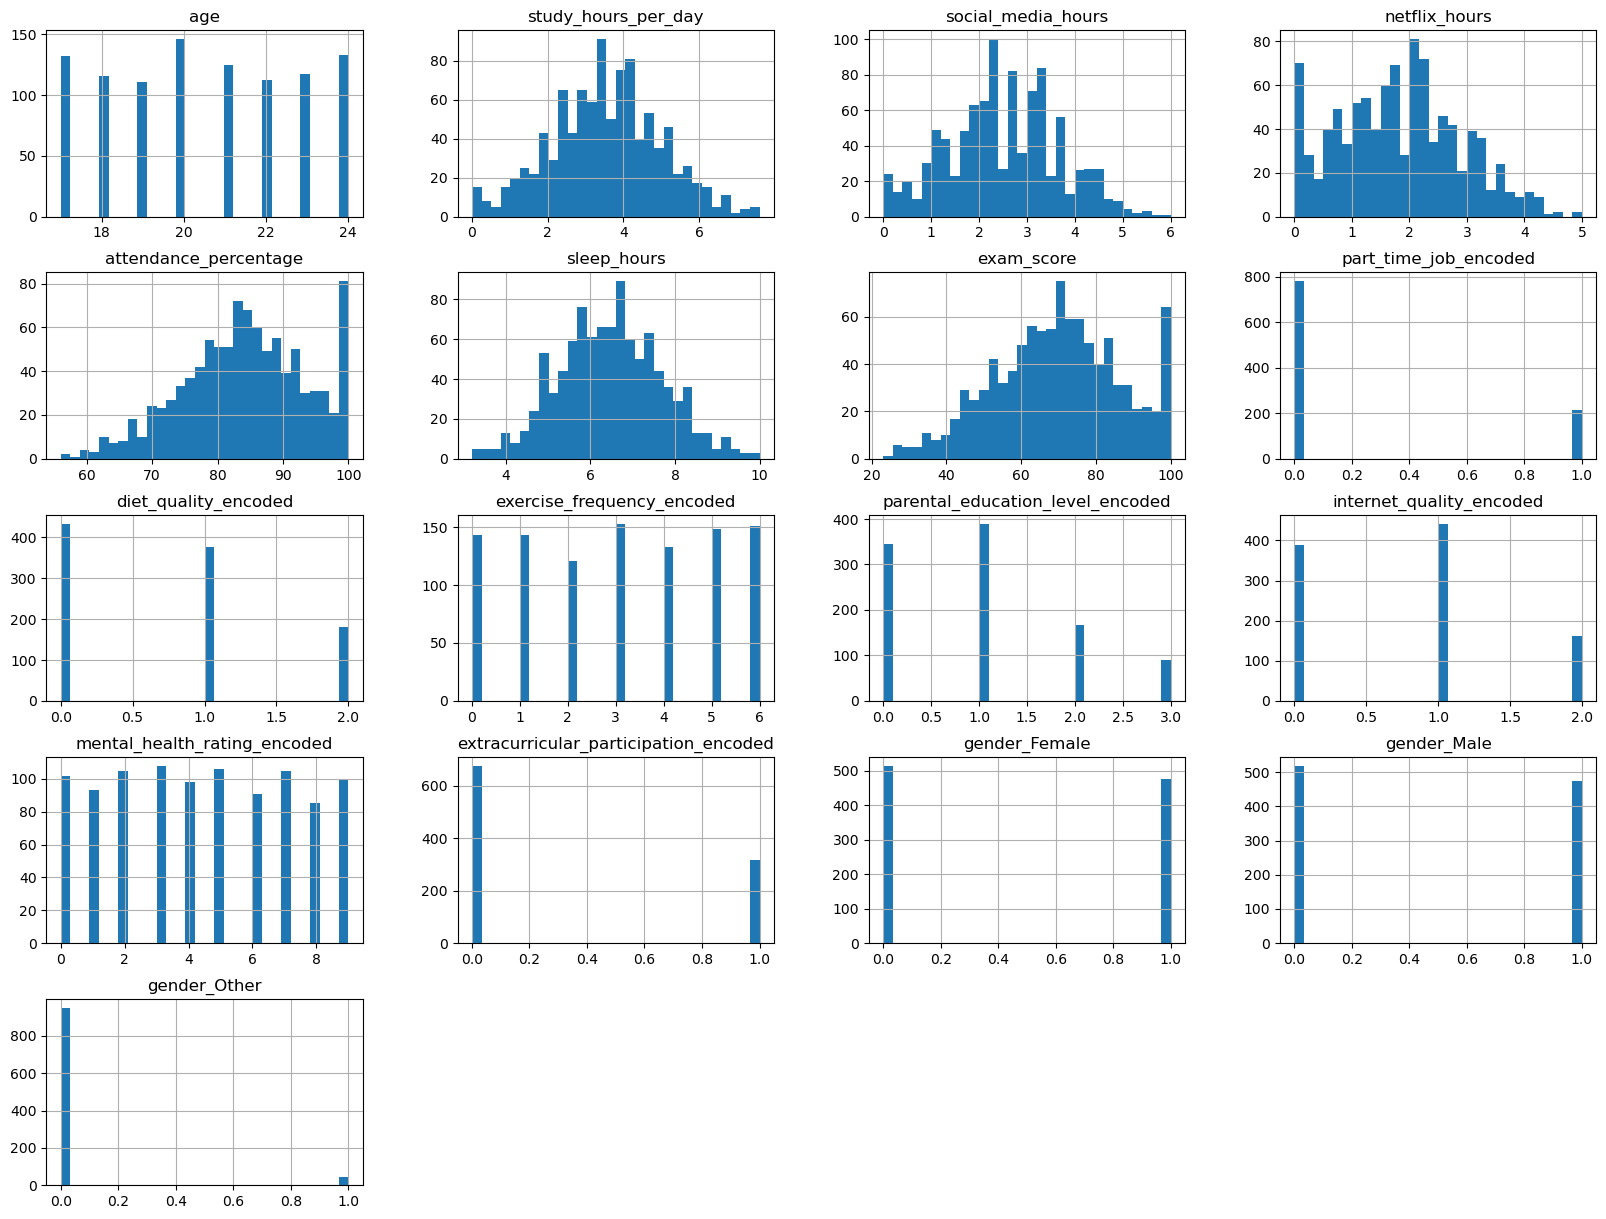

In [215]:
encoded_df.hist(bins=30, figsize=(20, 15))
plt.show()

In [216]:
# encoded_df.skew()

In [217]:
# encoded_df.columns

## EDA

## Correlation Heatmap

In [220]:
corma = encoded_df.corr()
cormax = corma['exam_score'].sort_values(ascending=False)
cormax

exam_score                               1.000000
study_hours_per_day                      0.824307
mental_health_rating_encoded             0.319113
exercise_frequency_encoded               0.152952
sleep_hours                              0.124239
attendance_percentage                    0.088507
gender_Female                            0.016695
gender_Other                             0.012758
extracurricular_participation_encoded   -0.006180
age                                     -0.011105
gender_Male                             -0.021844
parental_education_level_encoded        -0.028263
internet_quality_encoded                -0.029373
part_time_job_encoded                   -0.029515
diet_quality_encoded                    -0.050932
social_media_hours                      -0.164083
netflix_hours                           -0.167123
Name: exam_score, dtype: float64

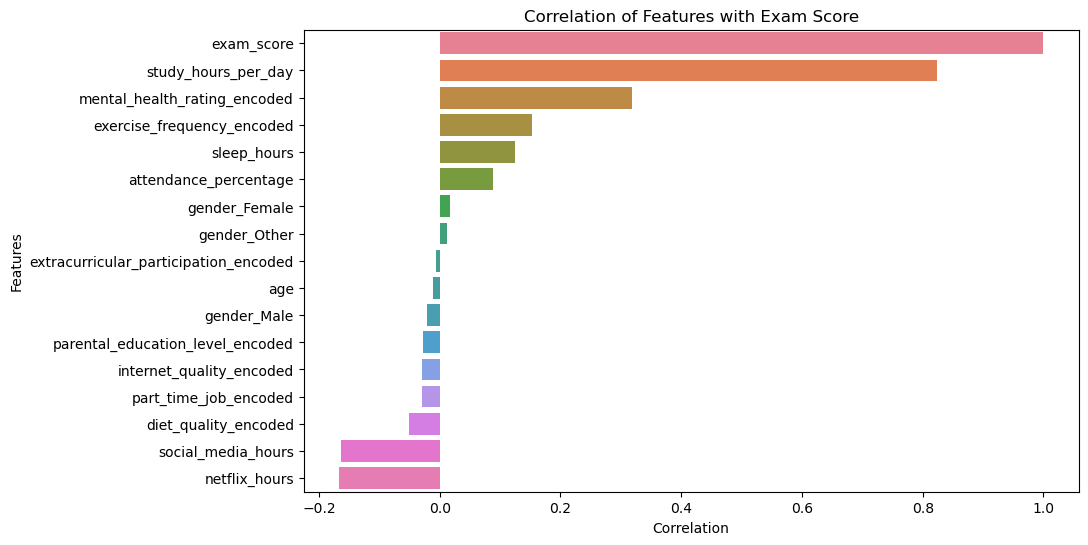

In [225]:
plt.figure(figsize=(10, 6))
sns.barplot(x=cormax.values, y=cormax.index, hue=cormax.index)
plt.title('Correlation of Features with Exam Score')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()

# study_hours_per_day is the most important factor (contribute the most)
# mental_health_rating, exercise_frequency, sleep_hours and attendance_percentage increase the exam scores (positive)
# netflix_hours, social_media_hours, diet_quality, part_time_job, internet_quality and parental_education_level lower the exam scores (negative)
# gender, age and extracurricular_participation has little to no affect (basically neutral)

## Key Analysis Question

- 1. What factors most influence students exam scores?
- 2. How strongly do academic habits (study hours, attendance) affect exam scores?
- 3. How do non-academic behaviors (social media hours, netflix hours, sleep hours) impact exam scores?
- 4. Does family background (parental education level, internet quality at home) impact exam scores?
- 5. How does mental health relate to exam scores?

In [228]:
# Ques 1 : What factors most influence students exam scores?
# Ans : study_hours_per_day is the most factor that affect the exam score, then followed by mental_health_rating, exercise_frequency, sleep_hours and attendance_percentage

In [230]:
# encoded_df.columns

In [232]:
corr1 = encoded_df[['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'diet_quality_encoded', 'exercise_frequency_encoded', 'parental_education_level_encoded', 'internet_quality_encoded', 'mental_health_rating_encoded', 'part_time_job_encoded', 'exam_score']].corr()
corr1

,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality_encoded,exercise_frequency_encoded,parental_education_level_encoded,internet_quality_encoded,mental_health_rating_encoded,part_time_job_encoded,exam_score
study_hours_per_day,1.000000,0.023837,-0.027636,0.024766,-0.026648,-0.074233,-0.035924,0.027204,-0.022978,-0.010456,-0.034839,0.824307
social_media_hours,0.023837,1.000000,0.003324,0.037690,0.021721,0.027555,-0.032397,0.022447,0.022271,-0.001422,0.016794,-0.164083
netflix_hours,-0.027636,0.003324,1.000000,0.001854,-0.011618,0.026614,-0.003318,-0.017189,-0.026247,0.013591,0.009620,-0.167123
attendance_percentage,0.024766,0.037690,0.001854,1.000000,0.015544,-0.005453,-0.008941,0.005647,0.038577,-0.020918,-0.042875,0.088507
sleep_hours,-0.026648,0.021721,-0.011618,0.015544,1.000000,0.020599,0.020557,-0.018775,-0.011734,-0.003169,0.003116,0.124239
diet_quality_encoded,-0.074233,0.027555,0.026614,-0.005453,0.020599,1.000000,0.042532,0.017297,-0.022743,0.060216,0.003649,-0.050932
exercise_frequency_encoded,-0.035924,-0.032397,-0.003318,-0.008941,0.020557,0.042532,1.000000,-0.028161,0.007437,-0.005083,-0.022902,0.152952
parental_education_level_encoded,0.027204,0.022447,-0.017189,0.005647,-0.018775,0.017297,-0.028161,1.000000,-0.006072,-0.092803,0.013092,-0.028263
internet_quality_encoded,-0.022978,0.022271,-0.026247,0.038577,-0.011734,-0.022743,0.007437,-0.006072,1.000000,-0.016720,-0.069479,-0.029373
mental_health_rating_encoded,-0.010456,-0.001422,0.013591,-0.020918,-0.003169,0.060216,-0.005083,-0.092803,-0.016720,1.000000,0.010360,0.319113


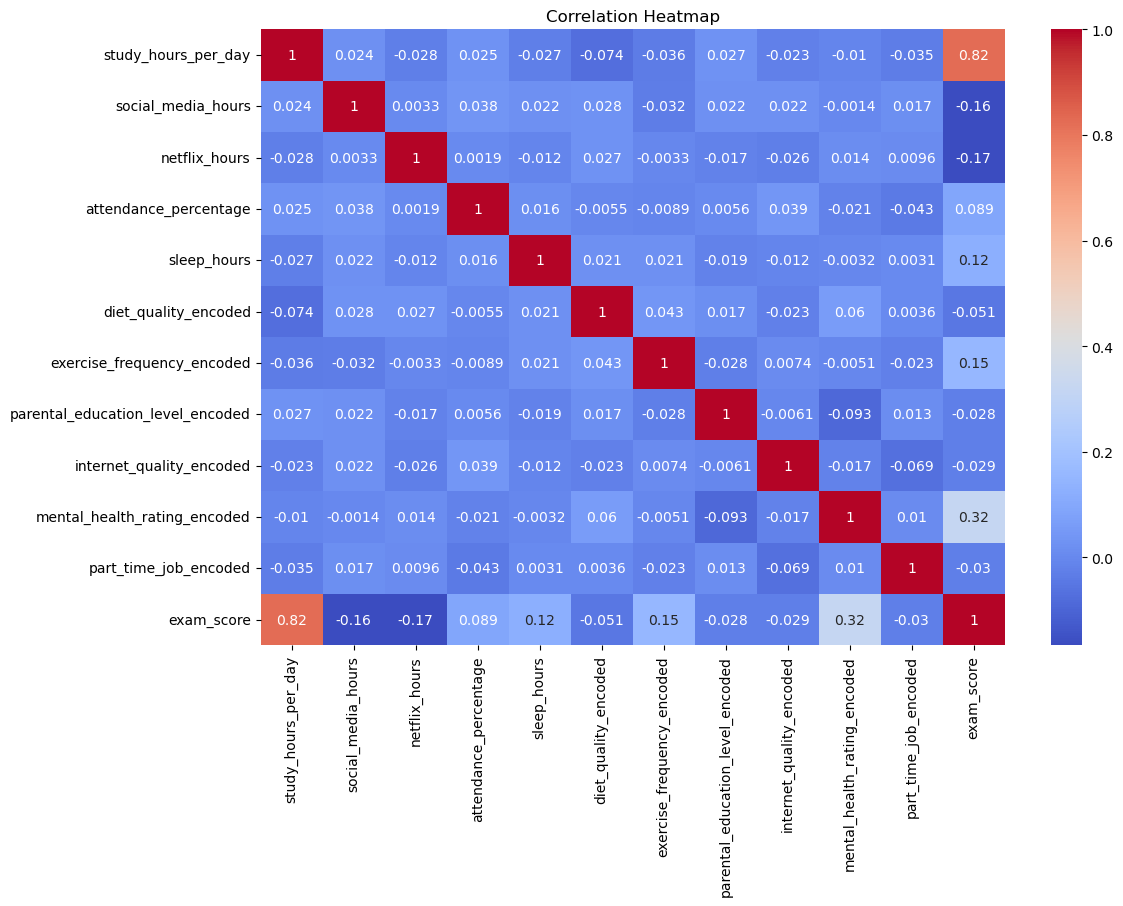

In [234]:
plt.figure(figsize=(12,8))
sns.heatmap(corr1, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Full Correlation Heatmap (Just for fun)

In [237]:
corr2 = encoded_df.corr()
corr2

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exam_score,part_time_job_encoded,diet_quality_encoded,exercise_frequency_encoded,parental_education_level_encoded,internet_quality_encoded,mental_health_rating_encoded,extracurricular_participation_encoded,gender_Female,gender_Male,gender_Other
age,1.000000,0.002040,-0.005712,-0.009651,-0.024413,0.032116,-0.011105,-0.008366,-0.012171,-0.003860,-0.003265,0.042176,-0.041915,-0.003796,-0.035933,0.029706,0.015477
study_hours_per_day,0.002040,1.000000,0.023837,-0.027636,0.024766,-0.026648,0.824307,-0.034839,-0.074233,-0.035924,0.027204,-0.022978,-0.010456,-0.009227,0.032336,-0.036231,0.009634
social_media_hours,-0.005712,0.023837,1.000000,0.003324,0.037690,0.021721,-0.164083,0.016794,0.027555,-0.032397,0.022447,0.022271,-0.001422,-0.016377,0.000650,-0.008158,0.018621
netflix_hours,-0.009651,-0.027636,0.003324,1.000000,0.001854,-0.011618,-0.167123,0.009620,0.026614,-0.003318,-0.017189,-0.026247,0.013591,0.005060,-0.029411,0.009758,0.048772
attendance_percentage,-0.024413,0.024766,0.037690,0.001854,1.000000,0.015544,0.088507,-0.042875,-0.005453,-0.008941,0.005647,0.038577,-0.020918,-0.019412,0.026878,-0.026428,-0.001139
sleep_hours,0.032116,-0.026648,0.021721,-0.011618,0.015544,1.000000,0.124239,0.003116,0.020599,0.020557,-0.018775,-0.011734,-0.003169,0.031653,-0.003403,-0.019740,0.057406
exam_score,-0.011105,0.824307,-0.164083,-0.167123,0.088507,0.124239,1.000000,-0.029515,-0.050932,0.152952,-0.028263,-0.029373,0.319113,-0.006180,0.016695,-0.021844,0.012758
part_time_job_encoded,-0.008366,-0.034839,0.016794,0.009620,-0.042875,0.003116,-0.029515,1.000000,0.003649,-0.022902,0.013092,-0.069479,0.010360,-0.020290,-0.031546,0.026731,0.011971
diet_quality_encoded,-0.012171,-0.074233,0.027555,0.026614,-0.005453,0.020599,-0.050932,0.003649,1.000000,0.042532,0.017297,-0.022743,0.060216,0.061706,0.008583,-0.015809,0.017915
exercise_frequency_encoded,-0.003860,-0.035924,-0.032397,-0.003318,-0.008941,0.020557,0.152952,-0.022902,0.042532,1.000000,-0.028161,0.007437,-0.005083,-0.007114,-0.062935,0.066894,-0.009766


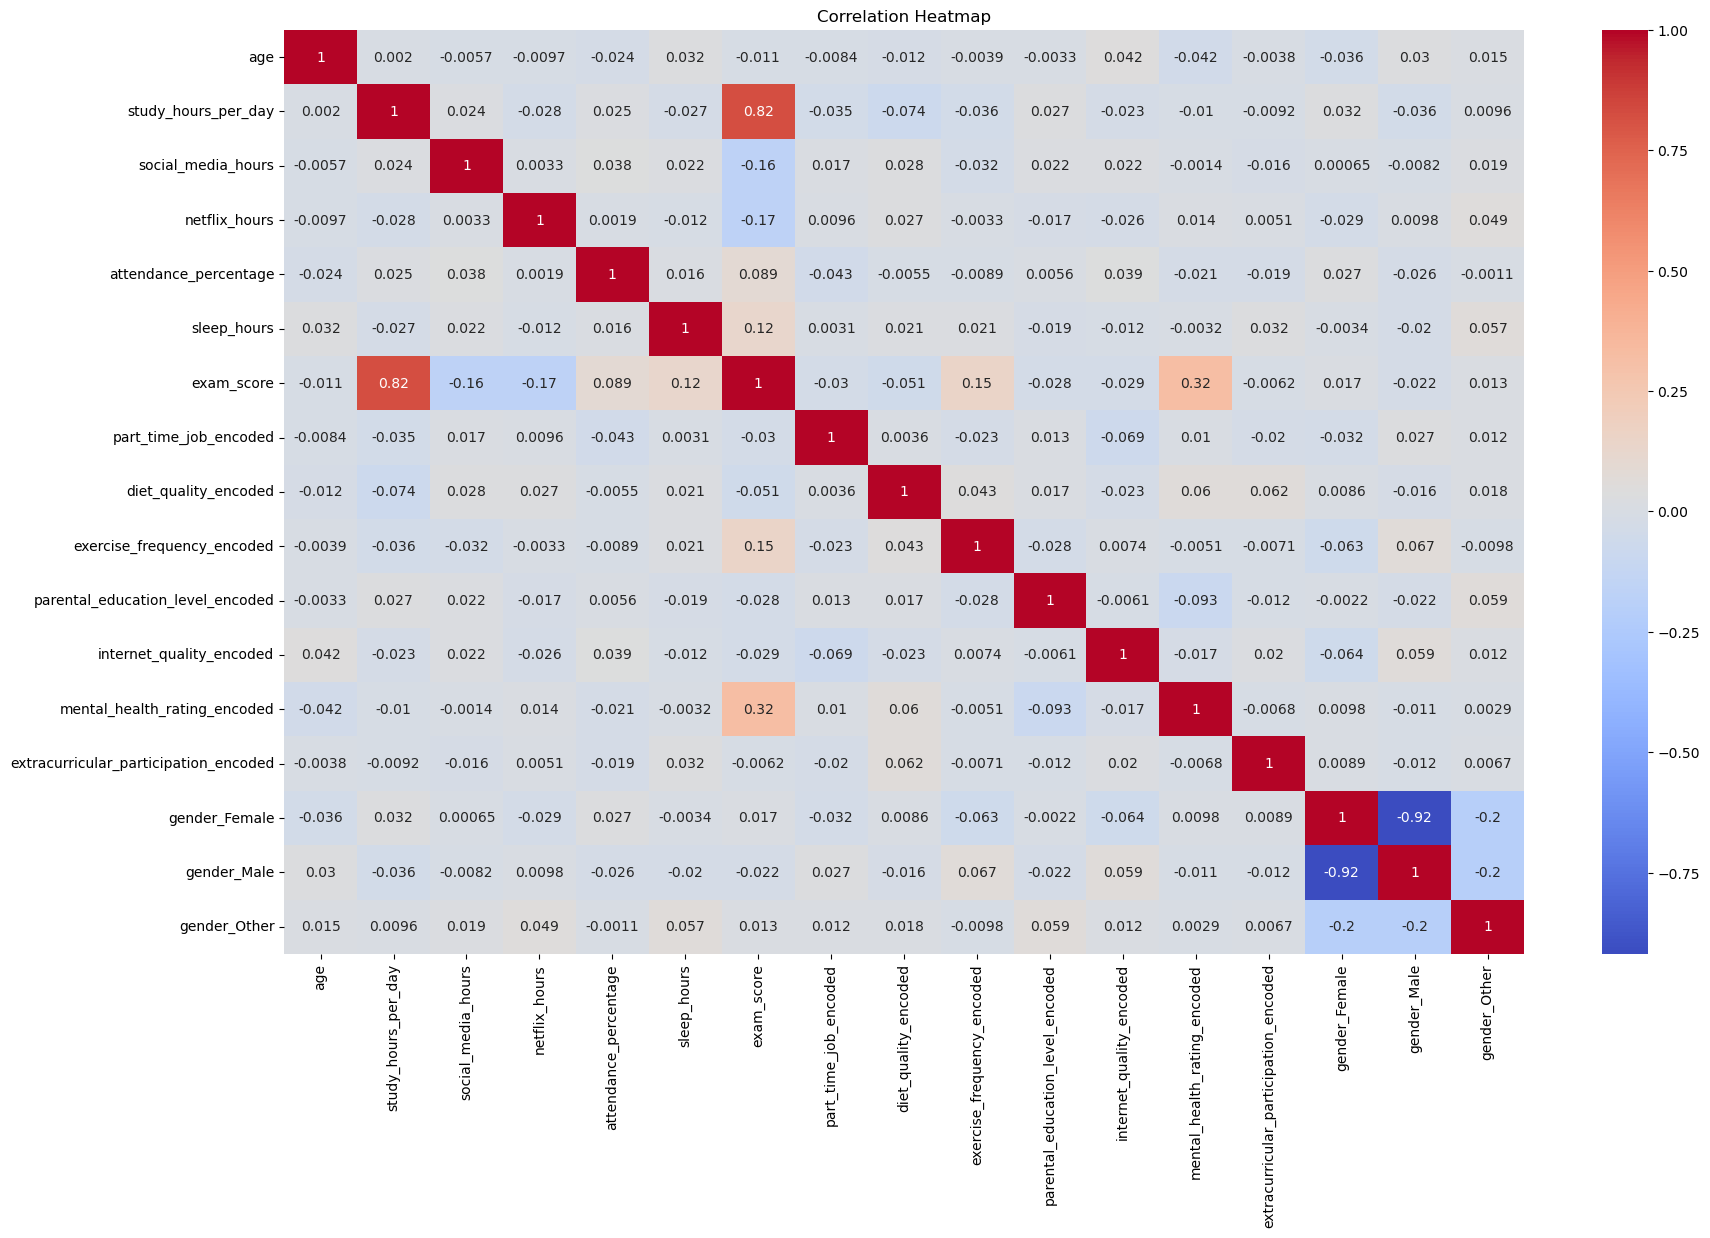

In [239]:
plt.figure(figsize=(20,12))
sns.heatmap(corr2, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [240]:
# encoded_df['exam_score'].dtypes

In [243]:
corr_df = encoded_df.corr()[['exam_score']].sort_values(by='exam_score', ascending=False)
corr_df.style.background_gradient(axis=None)

,exam_score
exam_score,1.000000
study_hours_per_day,0.824307
mental_health_rating_encoded,0.319113
exercise_frequency_encoded,0.152952
sleep_hours,0.124239
attendance_percentage,0.088507
gender_Female,0.016695
gender_Other,0.012758
extracurricular_participation_encoded,-0.006180
age,-0.011105


In [245]:
# Ques 2 : How strongly do academic habits (study hours, attendance) affect exam scores?
# Ans : Students who study more will get better results than those who only rely on classroom presence

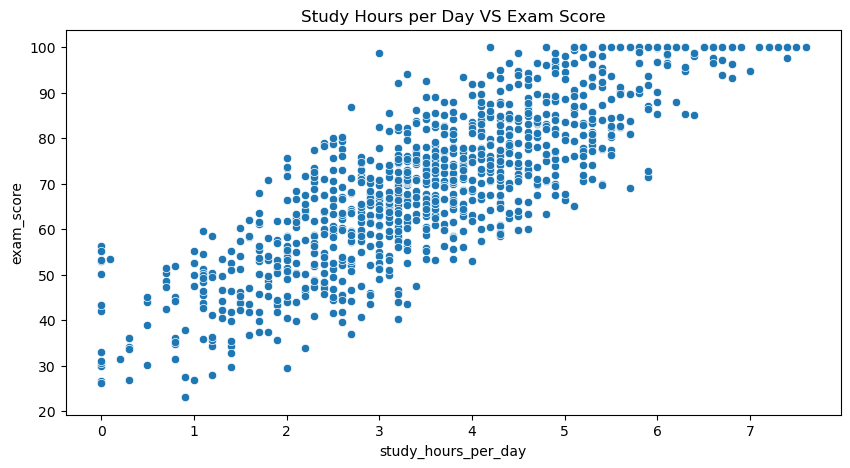

In [247]:
plt.figure(figsize=(10,5))
sns.scatterplot(encoded_df, x='study_hours_per_day', y='exam_score')
plt.title('Study Hours per Day VS Exam Score')
plt.show()

# higher study hour higher exam scores

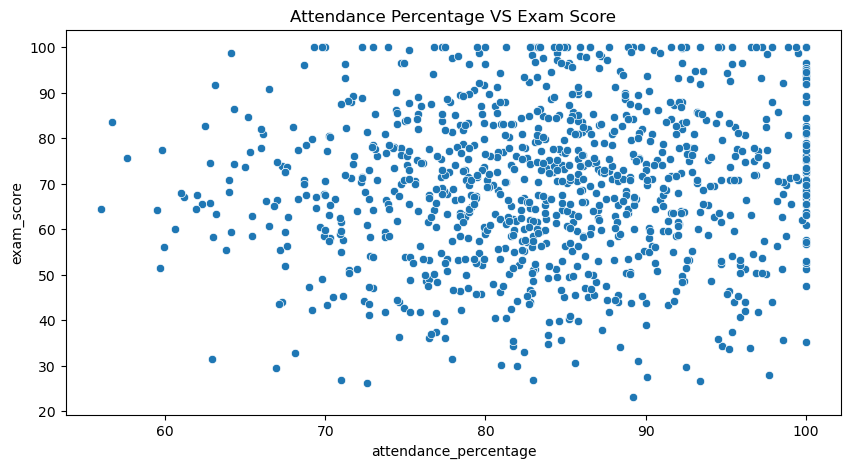

In [249]:
plt.figure(figsize=(10,5))
sns.scatterplot(encoded_df, x='attendance_percentage', y='exam_score')
plt.title('Attendance Percentage VS Exam Score')
plt.show()

# most student have 80 to 100 attendance
# Correlation is weak (0.088) means attendance doesn’t guarantee high score

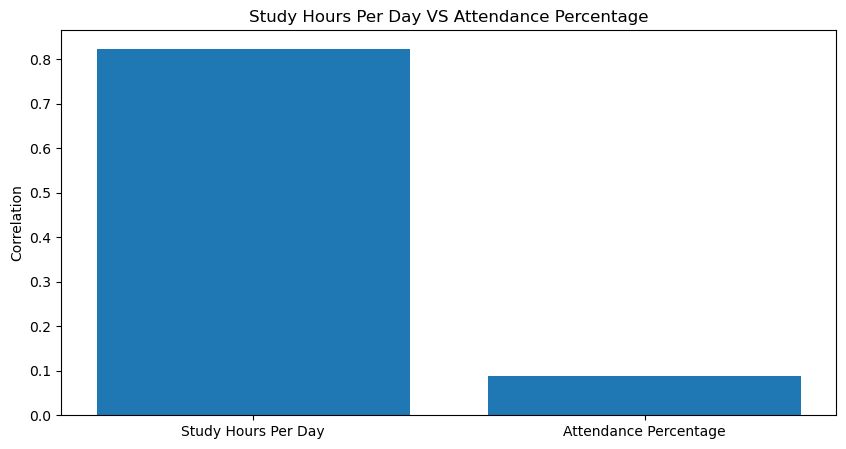

In [251]:
title = ['Study Hours Per Day', 'Attendance Percentage']
c = [0.824307, 0.088507]

plt.figure(figsize=(10, 5))
plt.bar(title, c)
plt.title('Study Hours Per Day VS Attendance Percentage')
plt.ylabel('Correlation')
plt.show()

# Study more is more important than attendance

In [253]:
# Ques 3 : How do non-academic behaviors (social media hours, netflix hours, sleep hours) impact exam scores?
# Ans : Students who spend more time on social media and netflix score lower in exam, while those who get more sleep and exercise regularly get better score.

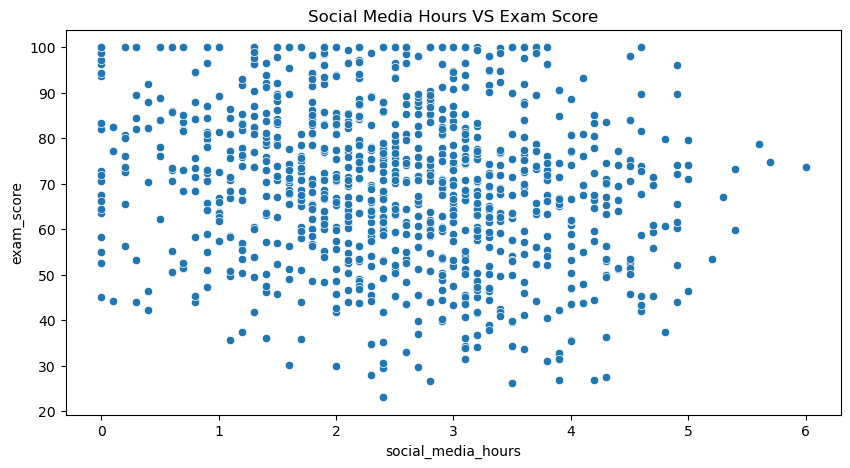

In [255]:
plt.figure(figsize=(10,5))
sns.scatterplot(encoded_df, x='social_media_hours', y='exam_score')
plt.title('Social Media Hours VS Exam Score')
plt.show()

# higher social media hours lower exam scores 

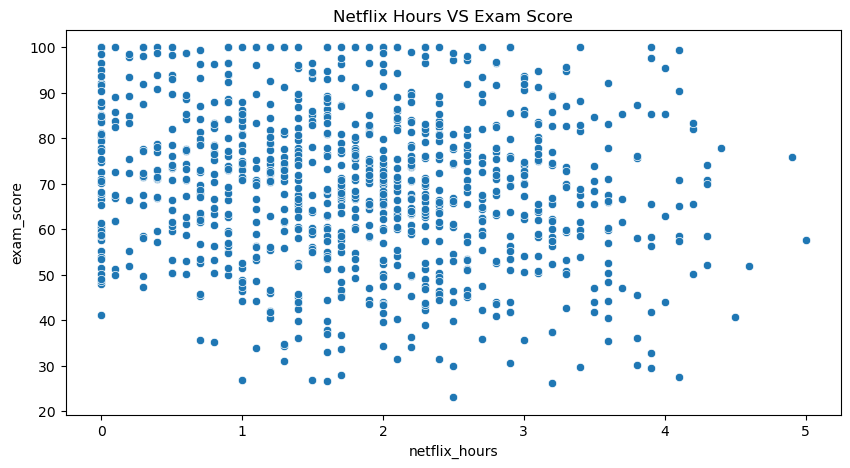

In [257]:
plt.figure(figsize=(10,5))
sns.scatterplot(encoded_df, x='netflix_hours', y='exam_score')
plt.title('Netflix Hours VS Exam Score')
plt.show()

# higher netflix hour lower exam score
# Watch netflix longer may replace study or rest time

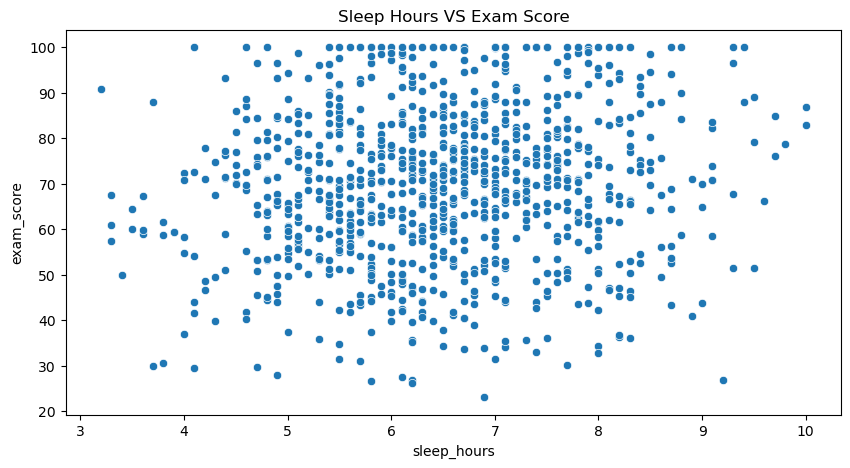

In [259]:
plt.figure(figsize=(10,5))
sns.scatterplot(encoded_df, x='sleep_hours', y='exam_score')
plt.title('Sleep Hours VS Exam Score')
plt.show()

# very little sleep (< 5 ) lower score
# better sleep get better score but not a major factor compared to study times

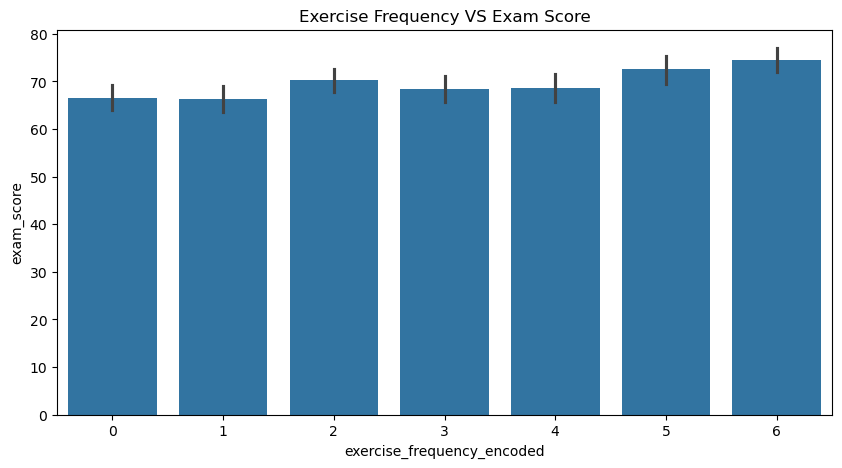

In [261]:
plt.figure(figsize=(10,5))
sns.barplot(encoded_df, x='exercise_frequency_encoded', y='exam_score')
plt.title('Exercise Frequency VS Exam Score')
plt.show()

# Higher exercise frequency higher exam score

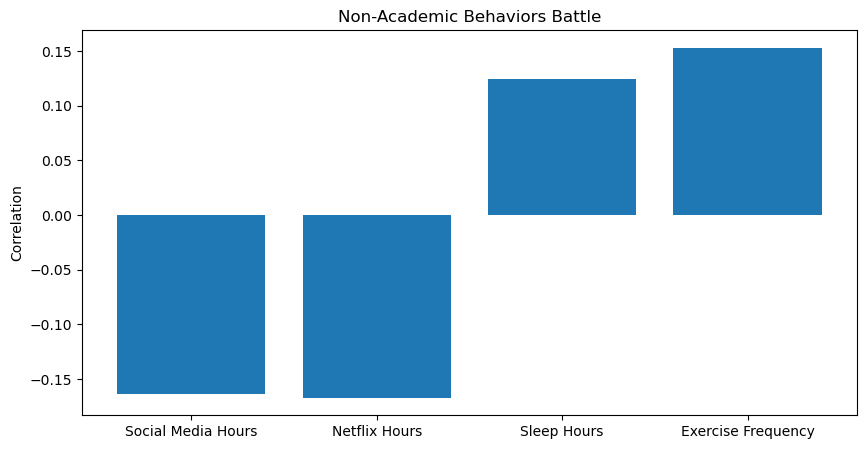

In [263]:
title2 = ['Social Media Hours', 'Netflix Hours', 'Sleep Hours', 'Exercise Frequency']
corre = [-0.164083, -0.167123, 0.124239, 0.152952]

plt.figure(figsize=(10, 5))
plt.bar(title2, corre)
plt.title('Non-Academic Behaviors Battle')
plt.ylabel('Correlation')
plt.show()

# More time on social media and netflix reduces exam score
# More exercise and sleep gets better score

In [265]:
# Ques 4 : Does family background (parental education level, internet quality at home) impact exam scores?
# Ans : Parental education level and internet quality shows very little to no impact on exam scores
# Student performance is affected by habit or behavior instead of family background

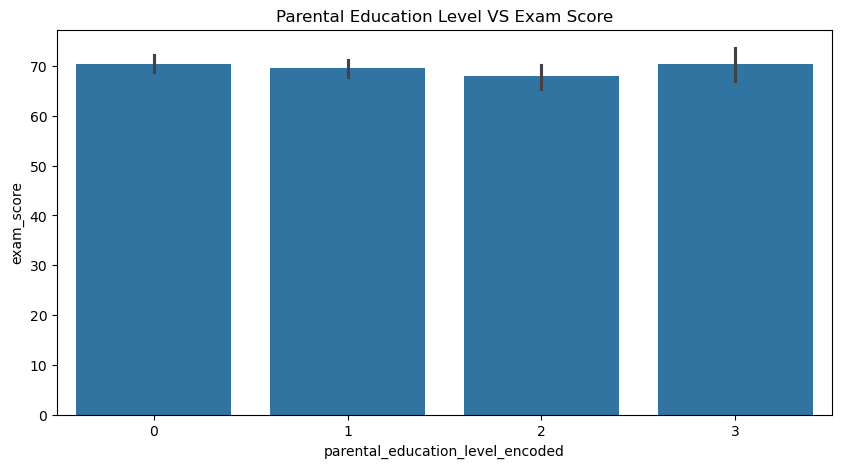

In [267]:
plt.figure(figsize=(10,5))
sns.barplot(encoded_df, x='parental_education_level_encoded', y='exam_score')
plt.title('Parental Education Level VS Exam Score')
plt.show()

# The bars are almost the same
# It doesnt affect much on student performance
# Self-discipline is more important

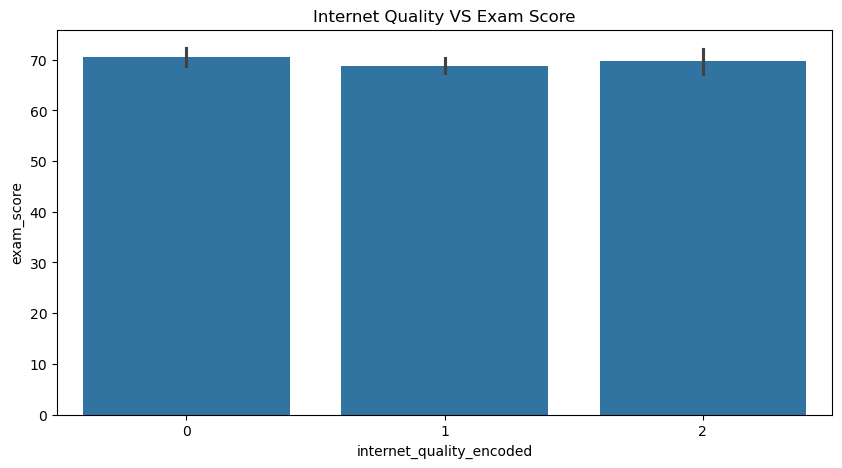

In [269]:
plt.figure(figsize=(10,5))
sns.barplot(encoded_df, x='internet_quality_encoded', y='exam_score')
plt.title('Internet Quality VS Exam Score')
plt.show()

# the difference is small
# but good internet quality show slightly lower scores

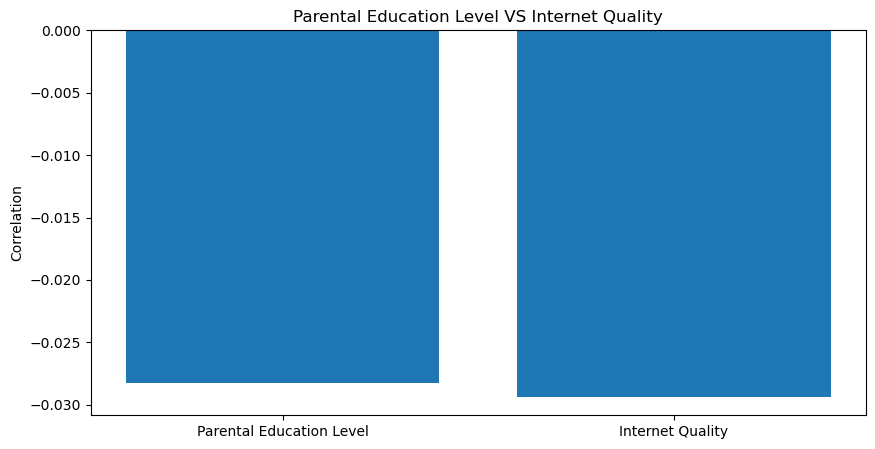

In [271]:
title3 = ['Parental Education Level', 'Internet Quality']
corra = [-0.028263, -0.029373]

plt.figure(figsize=(10, 5))
plt.bar(title3, corra)
plt.title('Parental Education Level VS Internet Quality')
plt.ylabel('Correlation')
plt.show()

# parental education level and internet quality have very weak and negative correlations with exam scores
# they have little or no affect on student performance

In [273]:
# Ques 5 : How does mental health relate to exam scores?
# Ans : Students with better mental health score higher in exams

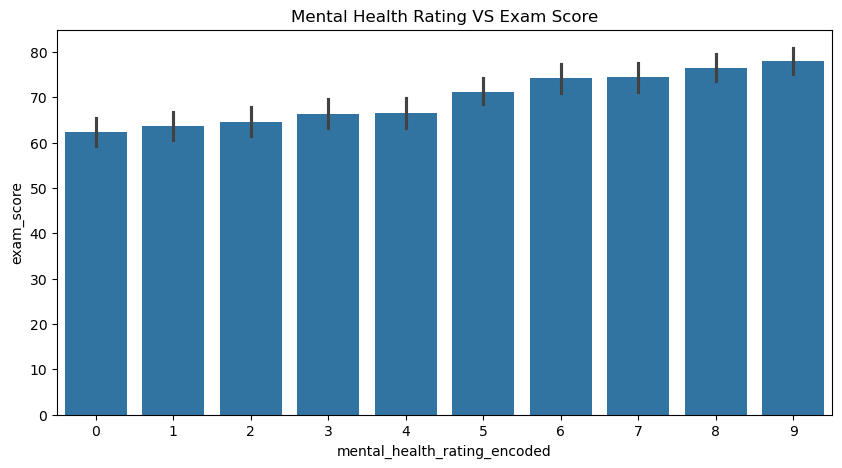

In [275]:
plt.figure(figsize=(10,5))
sns.barplot(encoded_df, x='mental_health_rating_encoded', y='exam_score')
plt.title('Mental Health Rating VS Exam Score')
plt.show()

# from both graph, higher mental health rating higher score

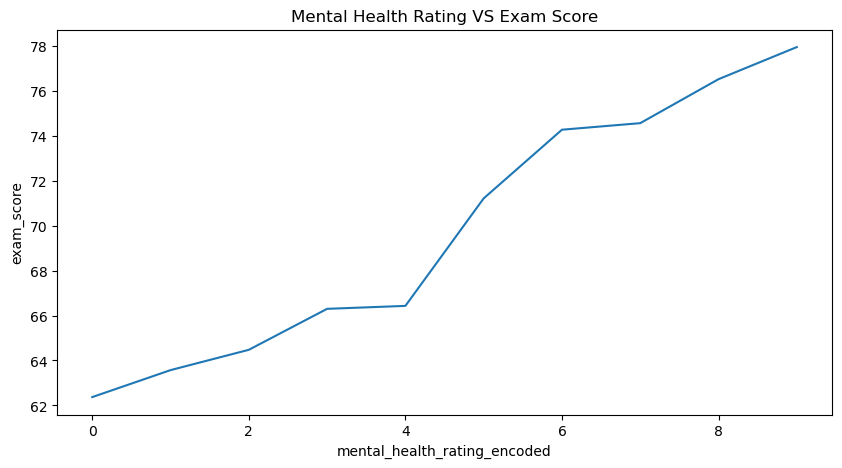

In [277]:
plt.figure(figsize=(10,5))
avg_health = encoded_df.groupby('mental_health_rating_encoded')['exam_score'].mean().reset_index()
sns.lineplot(avg_health, x='mental_health_rating_encoded', y='exam_score')
plt.title('Mental Health Rating VS Exam Score')
plt.show()

## Modeling

In [280]:
# linear regression
x = encoded_df.drop(['exam_score'],axis=1)
y = encoded_df.exam_score

In [282]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=21)

In [284]:
scaler = StandardScaler()

In [286]:
X_trains = scaler.fit_transform(X_train)
X_tests = scaler.transform(X_test)

In [288]:
lr_model = LinearRegression()

In [290]:
lr_model.fit(X_trains,y_train)

LinearRegression()

In [292]:
# x.columns

In [294]:
# x.columns[1]

In [296]:
# grab the coefficient of our model and the intercept 
coef = lr_model.coef_[1] # 1 is study hours
intercept = lr_model.intercept_

coef,intercept

(14.008765148813387, 69.74938775176342)

In [298]:
y_pred = lr_model.predict(X_tests)
y_pred.shape

(199,)

In [300]:
y_pred[:5]

array([87.143919, 62.081419, 89.518919, 57.518919, 79.847044])

In [302]:
# define our input
X_train_sm = sm.add_constant(X_trains)

# create a OLS model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# fit the data
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             exam_score   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     529.5
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        01:35:17   Log-Likelihood:                -2407.3
No. Observations:                 793   AIC:                             4847.
Df Residuals:                     777   BIC:                             4921.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.7454      0.181    386.016      0.000      69.391      70.100
x1            -0.0123      0.182     -0.067      0.946      -0.369       0.345
x2            13.9999      0.182     76.921      0.000      13.643      14.357
x3            -3.0806      0.182    -16.969      0.000      -3.437      -2.724
x4            -2.5486      0.181    -14.050      0.000      -2.905      -2.193
x5             1.4718      0.182      8.091      0.000       1.115       1.829
x6             2.4711      0.182     13.583      0.000       2.114       2.828
x7             0.0678      0.182      0.372      0.710      -0.290       0.425
x8            -0.2084      0.182     -1.143      0.254      -0.566       0.150
x9             2.9505      0.182     16.220      0.000       2.593       3.308
x10           -0.2937      0.183     -1.609      0.108      -0.652       0.065
x11           -0.2218      0.182     -1.217      0.224      -0.580       0.136
x12            5.6396      0.182     30.930      0.000       5.282       5.998
x13            0.0505      0.182      0.278      0.781      -0.306       0.407
x14           -0.1142      0.100     -1.144      0.253      -0.310       0.082
x15            0.0922      0.100      0.923      0.356      -0.104       0.288
x16            0.0523      0.167      0.313      0.755      -0.276       0.381
==============================================================================
Omnibus:                        1.154   Durbin-Watson:                   1.973
Prob(Omnibus):                  0.561   Jarque-Bera (JB):                1.001
Skew:                          -0.054   Prob(JB):                        0.606
Kurtosis:                       3.137   Cond. No.                     3.21e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.5e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [304]:
# make some confidence intervals, 95% by default
ols_model.conf_int()

,0,1
const,69.390719,70.100076
x1,-0.369315,0.344784
x2,13.642584,14.357133
x3,-3.436932,-2.724183
x4,-2.904744,-2.192543
x5,1.114716,1.828853
x6,2.113962,2.828211
x7,-0.289592,0.425152
x8,-0.566436,0.149634
x9,2.593426,3.307610


In [306]:
# estimate the p-values
pvalues = ols_model.pvalues
pvalues

const     0.000000e+00
x1        9.462517e-01
x2        0.000000e+00
x3        3.569670e-55
x4        4.047265e-40
x5        2.269094e-15
x6        7.348992e-38
x7        7.097627e-01
x8        2.535515e-01
x9        3.562800e-51
x10       1.080049e-01
x11       2.241399e-01
x12      1.495016e-137
x13       7.811921e-01
x14       2.529210e-01
x15       3.561662e-01
x16       7.545593e-01
dtype: float64

In [308]:
performance_table = evaluate_model_with_cross_validation(model=lr_model,X=X_trains,y=y_train)

In [310]:
performance_table

,Metric,Value,Threshold,Calculation,Performance
0,RMSE,5.178508,< 10%–20% of range,5.1785 / 76.90 * 100 ≈ 6.73%,Excellent
1,MAE,4.182818,< 10%–20% of range,4.1828 / 76.90 * 100 ≈ 5.44%,Excellent
2,R²,0.904931,"> 0.7 = Good, 0.5–0.7 = Acceptable, < 0.5 = Poor",N/A (unitless),Good
3,Explained Variance,0.906237,"> 0.7 = Good, 0.5–0.7 = Acceptable, < 0.5 = Poor",N/A (unitless),Good


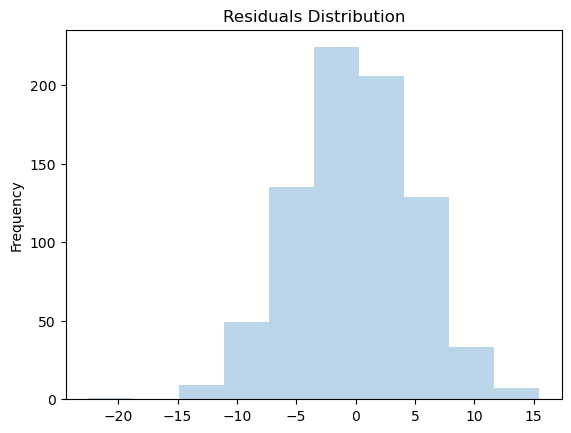

In [312]:
residuals = ols_model.resid
residuals.plot(kind='hist', alpha=0.3)
plt.title('Residuals Distribution')
plt.show()

In [314]:
plot_data = pd.DataFrame({'actual':y_test,'predicted':y_pred})

<Axes: xlabel='actual', ylabel='predicted'>

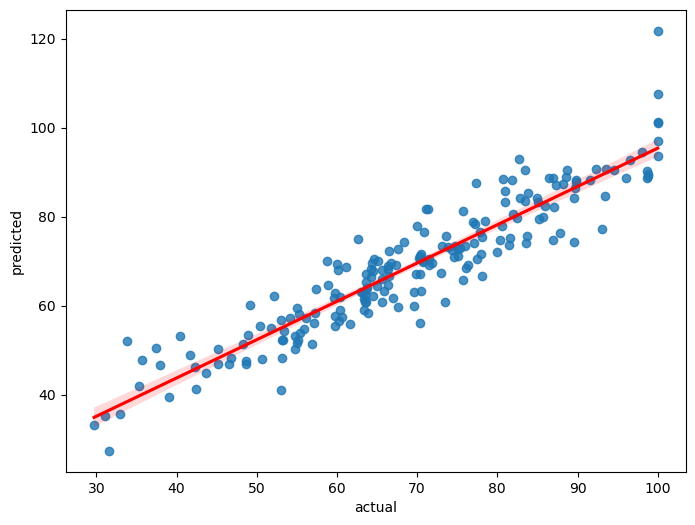

In [316]:
plt.figure(figsize=(8,6))
sns.regplot(data = plot_data, x='actual',y='predicted',line_kws={'color':'red'})

## Hypothesis Testing

In [319]:
# x.columns

### Index 0 = age

In [322]:
# do higher age higher score?
slope = lr_model.coef_[0]
if slope > 0:
    print('Yes')
else:
    print('No')

No


In [324]:
# is there strong relationship between age and exam score?
alpha = 0.05
# p_value = ols_model.pvalues[1] # start from 1 and is age
p_value = ols_model.pvalues.iloc[1] # use this prevent warning 
if p_value < alpha:
    print('Yes')
else:
    print('No')

No


### Index 1 = study_hours_per_day

In [327]:
# do higher study hour higher score?
slope = lr_model.coef_[1]
if slope > 0:
    print('Yes')
else:
    print('No')

Yes


In [329]:
# is there strong relationship between study hour and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[2] # use this prevent warning (access the third value which is study hour)
if p_value < alpha:
    print('Yes')
else:
    print('No')

Yes


In [331]:
# x.columns

### Index 2 = social_media_hours

In [334]:
# do higher social media hour higher score?
slope = lr_model.coef_[2]
if slope > 0:
    print('Yes')
else:
    print('No')

No


In [336]:
# is there strong relationship between social media hour and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[3] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

Yes


### Index 3 = netflix_hours

In [339]:
# do higher netflix hour higher score?
slope = lr_model.coef_[3]
if slope > 0:
    print('Yes')
else:
    print('No')

No


In [341]:
# is there strong relationship between netflix hour and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[4] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

Yes


### Index 4 = attendance_percentage

In [344]:
# do higher attendance percentage higher score?
slope = lr_model.coef_[4]
if slope > 0:
    print('Yes')
else:
    print('No')

Yes


In [346]:
# is there strong relationship between attendance percentage and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[5] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

Yes


### Index 5 = sleep_hours

In [349]:
# do higher sleep hour higher score?
slope = lr_model.coef_[5]
if slope > 0:
    print('Yes')
else:
    print('No')

Yes


In [351]:
# is there strong relationship between sleep hour and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[6] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

Yes


### Index 6 = part_time_job_encoded

In [354]:
# is part time job higher score?
slope = lr_model.coef_[6]
if slope > 0:
    print('Yes')
else:
    print('No')

Yes


In [356]:
# is there strong relationship between part time and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[7] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

No


### Index 7 = diet_quality_encoded

In [359]:
# is better diet quality higher score?
slope = lr_model.coef_[7]
if slope > 0:
    print('Yes')
else:
    print('No')

No


In [361]:
# is there strong relationship between diet quality and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[8] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

No


### Index 8 = exercise_frequency_encoded

In [364]:
# do higher exercise frequency higher score?
slope = lr_model.coef_[8]
if slope > 0:
    print('Yes')
else:
    print('No')

Yes


In [366]:
# is there strong relationship between exercise frequency and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[9] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

Yes


### Index 9 = parental_education_level_encoded

In [369]:
# do higher parent education level higher score?
slope = lr_model.coef_[9]
if slope > 0:
    print('Yes')
else:
    print('No')

No


In [371]:
# is there strong relationship between parental education level and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[10] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

No


### Index 10 = internet_quality_encoded

In [374]:
# is better internet quality higher score?
slope = lr_model.coef_[10]
if slope > 0:
    print('Yes')
else:
    print('No')

No


In [376]:
# is there strong relationship between internet quality and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[11] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

No


### Index 11 = mental_health_rating_encoded

In [379]:
# do higher mental health rating higher score?
slope = lr_model.coef_[11]
if slope > 0:
    print('Yes')
else:
    print('No')

Yes


In [381]:
# is there strong relationship between mental health rating and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[12] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

Yes


### Index 12 = extracurricular_participation_encoded

In [384]:
# do higher extracurricular participation higher score?
slope = lr_model.coef_[12]
if slope > 0:
    print('Yes')
else:
    print('No')

Yes


In [386]:
# is there strong relationship between extracurricular participation and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[13] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

No


### Index 13 = gender_Female

In [389]:
# is gender female higher score?
slope = lr_model.coef_[13]
if slope > 0:
    print('Yes')
else:
    print('No')

Yes


In [391]:
# is there strong relationship between gender female and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[14] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

No


### Index 14 = gender_Male

In [394]:
# is gender male higher score?
slope = lr_model.coef_[14]
if slope > 0:
    print('Yes')
else:
    print('No')

Yes


In [396]:
# is there strong relationship between gender male and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[15] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

No


### Index 15 = gender_Other

In [399]:
# is those prefer not to say higher score?
slope = lr_model.coef_[15]
if slope > 0:
    print('Yes')
else:
    print('No')

Yes


In [401]:
# is there strong relationship between gender other (prefer not to say) and exam score?
alpha = 0.05
p_value = ols_model.pvalues.iloc[16] 
if p_value < alpha:
    print('Yes')
else:
    print('No')

No


In [403]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Support Vector Regression': SVR(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'KNN Regression': KNeighborsRegressor(),
    'Random Forest Regression': RandomForestRegressor(),
    'AdaBoost Regression': AdaBoostRegressor(),
    'XGBoost Regression':xgb.XGBRegressor(),
}

In [405]:
# Evaluate models
results = []
for name,model in models.items():
    pipeline = Pipeline([
        ('regressor',model),
    ])
    pipeline.fit(X_train,y_train)
    y_pred2 = pipeline.predict(X_test)
    results.append({
        'model':name,
        'R2_score': r2_score(y_test,y_pred2),
        'MSE': mean_squared_error(y_test,y_pred2)
    })

In [406]:
df1 = pd.DataFrame(results)
df1.sort_values(by='R2_score', ascending=False)

,model,R2_score,MSE
0,Linear Regression,0.865954,35.717189
1,Ridge Regression,0.865945,35.719676
2,Lasso Regression,0.857185,38.053836
6,Random Forest Regression,0.837434,43.316523
8,XGBoost Regression,0.825344,46.538014
7,AdaBoost Regression,0.791846,55.463824
4,Decision Tree Regression,0.644500,94.725025
5,KNN Regression,0.518378,128.330913
3,Support Vector Regression,0.034179,257.348390


In [407]:
# Since we have high accuracy already, we dont need to do grid search (i also not sure how to do ~)

## Add ensemble model (Voting Regressor)

In [412]:
voting = VotingRegressor(estimators=[
    ('linearRegression', LinearRegression()),
    ('ridge', Ridge()),
    ('lasso', Lasso())
])

In [414]:
results = []
for name,model in [('voting regressor', voting)]:
    pipeline = Pipeline([
        ('regressor',model),
    ])
    pipeline.fit(X_train,y_train)
    y_pred3 = pipeline.predict(X_test)
    results.append({
        'model':name,
        'R2_score': r2_score(y_test,y_pred3),
        'MSE': mean_squared_error(y_test,y_pred3)
    })

In [416]:
df2 = pd.DataFrame(results)
df2.sort_values(by='R2_score', ascending=False)

,model,R2_score,MSE
0,voting regressor,0.866132,35.67


## Test

In [419]:
model_ = {
    'model':lr_model,
    'scaler': scaler, 
    'feature_names':x.columns.tolist(),
}

In [421]:
import joblib

In [423]:
joblib.dump(model_,'exam_score_model2.joblib')

['exam_score_model2.joblib']

In [425]:
## end of test

## Saving the model file

In [428]:
joblib.dump(lr_model,'exam_score_model.joblib')

['exam_score_model.joblib']

In [430]:
# x.columns

## Quick demo

In [433]:
import gradio as gr
print(gr.__version__)

5.25.2


In [434]:
# x

In [435]:
# x.columns

In [436]:
model = joblib.load('exam_score_model2.joblib')
model

{'model': LinearRegression(),
 'scaler': StandardScaler(),
 'feature_names': ['age',
  'study_hours_per_day',
  'social_media_hours',
  'netflix_hours',
  'attendance_percentage',
  'sleep_hours',
  'part_time_job_encoded',
  'diet_quality_encoded',
  'exercise_frequency_encoded',
  'parental_education_level_encoded',
  'internet_quality_encoded',
  'mental_health_rating_encoded',
  'extracurricular_participation_encoded',
  'gender_Female',
  'gender_Male',
  'gender_Other']}

In [437]:
model = joblib.load('exam_score_model2.joblib')
lr_model = model['model']
scaler = model['scaler']
features_names = model['feature_names']

def predict_exam_score(age, study_hours_per_day, social_media_hours, netflix_hours, attendance_percentage, sleep_hours, part_time_job, diet_quality, exercise_frequency, parental_education_level, internet_quality, mental_health_rating, extracurricular_participation, gender):
    diet_quality_map = {'Poor': 0, 'Fair': 1, 'Good': 2}
    internet_quality_map = {'Poor': 0, 'Average': 1, 'Good': 2}
    part_time_job_map = {'No': 0, 'Yes': 1}
    parental_education_map = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'Unknown': 3}
    extracurricular_map = {'No': 0, 'Yes': 1}
    
    gender_female = 1 if gender == 'Female' else 0
    gender_male = 1 if gender == 'Male' else 0
    gender_other = 1 if gender == 'Other' else 0
    
    input_data = pd.DataFrame({
        'age': [age],
        'study_hours_per_day': [study_hours_per_day],
        'social_media_hours': [social_media_hours],
        'netflix_hours': [netflix_hours],
        'attendance_percentage': [attendance_percentage],
        'sleep_hours': [sleep_hours],
        'part_time_job_encoded': [part_time_job_map[part_time_job]],
        'diet_quality_encoded': [diet_quality_map[diet_quality]],
        'exercise_frequency_encoded': [exercise_frequency],
        'parental_education_level_encoded': [parental_education_map[parental_education_level]],
        'internet_quality_encoded': [internet_quality_map[internet_quality]],
        'mental_health_rating_encoded': [mental_health_rating],
        'extracurricular_participation_encoded': [extracurricular_map[extracurricular_participation]],
        'gender_Female': [gender_female],
        'gender_Male': [gender_male],
        'gender_Other': [gender_other],
    })

    input_scaled = scaler.transform(input_data)
    prediction = lr_model.predict(input_scaled)[0]
    prediction = max(0, min(100, prediction))
    return f"{prediction:.2f} scores"

with gr.Blocks(title='Predict Exam Score Demo') as demo:
    gr.Markdown('Exam Score Prediction')
    with gr.Row():
        with gr.Column():
            age = gr.Slider(18, 50, step=1, label='Age')
            study_hours_per_day = gr.Slider(0, 10, step=0.5, label='Study Hours Per Day')
            social_media_hours = gr.Slider(0, 10, step=0.5, label='Social Media Hours per Day')
            netflix_hours = gr.Slider(0, 10, step=0.5, label='Netflix Hours per Day')
            attendance_percentage = gr.Slider(0, 100, step=1, label='Attendance Percentage (%)')
            sleep_hours = gr.Slider(0, 12, step=0.5, label='Sleep Hours Per Night')
            
            part_time_job = gr.Radio(
                choices=['Yes', 'No'], 
                label='Part-Time Job',
            )
            
            diet_quality = gr.Radio(
                choices=['Poor', 'Fair', 'Good'],
                label='Diet Quality',
            )
            
            exercise_frequency = gr.Slider(0, 7, step=1, label='Exercise Days per Week')
            
            parental_education_level = gr.Radio(
                choices=['High School', 'Bachelor', 'Master', 'Unknown'], 
                label='Parental Education Level',
            )
            
            internet_quality = gr.Radio(
                choices=['Poor', 'Average', 'Good'], 
                label='Internet Quality at Home',
            )
            
            mental_health_rating = gr.Slider(1, 10, step=1, label='Mental Health Rating (1-10)')
            
            extracurricular_participation = gr.Radio(
                choices=['Yes', 'No'], 
                label='Extracurricular Participation',
            )
            
            gender = gr.Radio(
                choices=['Female', 'Male', 'Other'],
                label='Gender',
            )

            predict_button = gr.Button('Predict Exam Score')
            prediction_output = gr.Textbox(label='Predicted Exam Score', value='Click Predict to see result')

    predict_button.click(
        fn=predict_exam_score,
        inputs=[age, study_hours_per_day, social_media_hours, netflix_hours, attendance_percentage,sleep_hours, part_time_job, diet_quality, exercise_frequency,parental_education_level, internet_quality, mental_health_rating,extracurricular_participation, gender],
        outputs=prediction_output
    )

if __name__ == '__main__':
    demo.launch(share=True) # share live (qr code)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://c10391678b047ee580.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
